# Análisis de Accidentabilidad Laboral en Chile

## Proyecto de Data Science aplicado a Prevención de Riesgos

Este notebook forma parte de un proyecto de portafolio orientado a aplicar análisis de datos al ámbito de la Prevención de Riesgos Laborales.

El análisis utiliza datos públicos de la Superintendencia de Seguridad Social disponibles en el portal Datos Abiertos del Estado de Chile.

El objetivo es analizar la evolución de los accidentes del trabajo y de trayecto, relacionarlos con la cantidad de trabajadoras y trabajadores protegidos, y construir indicadores útiles para la gestión preventiva.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

ruta_raw = Path("../data/raw")

archivo_accidentes = ruta_raw / "accidentes_trabajo_trayecto.csv"
archivo_trabajadores = ruta_raw / "trabajadores_protegidos.csv"

In [2]:
df_accidentes = pd.read_csv(
    archivo_accidentes,
    sep="|",
    encoding="utf-8-sig"
)

df_trabajadores = pd.read_csv(
    archivo_trabajadores,
    sep="|",
    encoding="utf-8-sig"
)

df_accidentes.head()

,Región,Actividad Económica CIIU,Periodo,Origen,Tamaño de empresa,Año,Agente del accidente,Forma del accidente,Parte del cuerpo,Organismo Administrador,Mujer,Hombre,Sin información,Total
0,Aysén del Gral. Carlos Ibañez del Campo,"Actividades inmobiliarias, empresariales y de ...",2015-01,Accidentes del trabajo,"""101-199""",2015,Sin Información,Sin Información,Sin información,A.CH.S.,0,1,0,1
1,Aysén del Gral. Carlos Ibañez del Campo,"Actividades inmobiliarias, empresariales y de ...",2015-01,Accidentes del trabajo,"""200-499""",2015,Sin Información,Sin Información,Sin información,MUSEG,0,1,0,1
2,Aysén del Gral. Carlos Ibañez del Campo,"Actividades inmobiliarias, empresariales y de ...",2015-03,Accidentes de trayecto,"""200-499""",2015,Sin Información,Sin Información,Sin información,MUSEG,0,1,0,1
3,Aysén del Gral. Carlos Ibañez del Campo,"Actividades inmobiliarias, empresariales y de ...",2015-03,Accidentes del trabajo,"""10-25""",2015,Sin Información,Sin Información,Sin información,A.CH.S.,0,1,0,1
4,Aysén del Gral. Carlos Ibañez del Campo,"Actividades inmobiliarias, empresariales y de ...",2015-03,Accidentes del trabajo,"""50-100""",2015,Sin Información,Sin Información,Sin información,A.CH.S.,0,2,0,2


In [3]:
df_trabajadores.head()

,Tamaño de empresa,periodo,Actividad Económica CIIU,region,periodoano,organismoadministrador,Mujer,Hombre,Sin información,Total
0,"""1-9""",2015-01,"Actividades inmobiliarias, empresariales y de ...",Aysén del Gral. Carlos Ibañez del Campo,2015,A.CH.S.,27,16,0,43
1,"""1-9""",2015-01,"Actividades inmobiliarias, empresariales y de ...",Aysén del Gral. Carlos Ibañez del Campo,2015,I.S.L,121,104,0,225
2,"""1-9""",2015-01,"Actividades inmobiliarias, empresariales y de ...",Aysén del Gral. Carlos Ibañez del Campo,2015,I.S.T.,1,3,0,4
3,"""1-9""",2015-01,"Actividades inmobiliarias, empresariales y de ...",Aysén del Gral. Carlos Ibañez del Campo,2015,MUSEG,61,46,0,107
4,"""1-9""",2015-01,"Actividades inmobiliarias, empresariales y de ...",De Antofagasta,2015,A.CH.S.,116,210,0,326


In [4]:
df_accidentes.shape, df_trabajadores.shape

((728284, 14), (629224, 10))

In [5]:
df_accidentes.columns

Index(['Región', 'Actividad Económica CIIU', 'Periodo', 'Origen',
       'Tamaño de empresa', 'Año', 'Agente del accidente',
       'Forma del accidente', 'Parte del cuerpo', 'Organismo Administrador',
       'Mujer', 'Hombre', 'Sin información', 'Total'],
      dtype='object')

In [6]:
df_trabajadores.columns

Index(['Tamaño de empresa', 'periodo', 'Actividad Económica CIIU', 'region',
       'periodoano', 'organismoadministrador', 'Mujer', 'Hombre',
       'Sin información', 'Total'],
      dtype='object')

## 1. Revisión inicial de las bases

En esta sección se revisa la estructura inicial de las bases descargadas desde Datos Abiertos Chile / SUSESO.

Se analizan dimensiones, columnas, tipos de datos y valores nulos para comprender la información disponible antes de realizar limpieza o transformaciones.

In [7]:
print("Base accidentes:")
print(df_accidentes.shape)

print("\nBase trabajadores protegidos:")
print(df_trabajadores.shape)

Base accidentes:
(728284, 14)

Base trabajadores protegidos:
(629224, 10)


In [8]:
df_accidentes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 728284 entries, 0 to 728283
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   Región                    728284 non-null  object
 1   Actividad Económica CIIU  728284 non-null  object
 2   Periodo                   728284 non-null  object
 3   Origen                    728284 non-null  object
 4   Tamaño de empresa         728284 non-null  object
 5   Año                       728284 non-null  int64 
 6   Agente del accidente      728284 non-null  object
 7   Forma del accidente       728284 non-null  object
 8   Parte del cuerpo          728284 non-null  object
 9   Organismo Administrador   728284 non-null  object
 10  Mujer                     728284 non-null  int64 
 11  Hombre                    728284 non-null  int64 
 12  Sin información           728284 non-null  int64 
 13  Total                     728284 non-null  int64 
dtypes: i

In [9]:
df_trabajadores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 629224 entries, 0 to 629223
Data columns (total 10 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   Tamaño de empresa         629224 non-null  object
 1   periodo                   629224 non-null  object
 2   Actividad Económica CIIU  629224 non-null  object
 3   region                    629224 non-null  object
 4   periodoano                629224 non-null  int64 
 5   organismoadministrador    629224 non-null  object
 6   Mujer                     629224 non-null  int64 
 7   Hombre                    629224 non-null  int64 
 8   Sin información           629224 non-null  int64 
 9   Total                     629224 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 48.0+ MB


In [10]:
nulos_accidentes = pd.DataFrame({
    "valores_nulos": df_accidentes.isnull().sum(),
    "porcentaje_nulos": (df_accidentes.isnull().mean() * 100).round(2)
})

nulos_accidentes

,valores_nulos,porcentaje_nulos
Región,0,0.0
Actividad Económica CIIU,0,0.0
Periodo,0,0.0
Origen,0,0.0
Tamaño de empresa,0,0.0
Año,0,0.0
Agente del accidente,0,0.0
Forma del accidente,0,0.0
Parte del cuerpo,0,0.0
Organismo Administrador,0,0.0


In [11]:
nulos_trabajadores = pd.DataFrame({
    "valores_nulos": df_trabajadores.isnull().sum(),
    "porcentaje_nulos": (df_trabajadores.isnull().mean() * 100).round(2)
})

nulos_trabajadores

,valores_nulos,porcentaje_nulos
Tamaño de empresa,0,0.0
periodo,0,0.0
Actividad Económica CIIU,0,0.0
region,0,0.0
periodoano,0,0.0
organismoadministrador,0,0.0
Mujer,0,0.0
Hombre,0,0.0
Sin información,0,0.0
Total,0,0.0


In [12]:
def limpiar_nombre_columna(columna):
    columna = columna.lower()
    columna = columna.replace("á", "a")
    columna = columna.replace("é", "e")
    columna = columna.replace("í", "i")
    columna = columna.replace("ó", "o")
    columna = columna.replace("ú", "u")
    columna = columna.replace("ñ", "n")
    columna = columna.replace(" ", "_")
    columna = columna.replace("(", "")
    columna = columna.replace(")", "")
    columna = columna.replace("/", "_")
    columna = columna.replace("-", "_")
    return columna

df_accidentes.columns = [limpiar_nombre_columna(col) for col in df_accidentes.columns]
df_trabajadores.columns = [limpiar_nombre_columna(col) for col in df_trabajadores.columns]

df_accidentes.columns

Index(['region', 'actividad_economica_ciiu', 'periodo', 'origen',
       'tamano_de_empresa', 'ano', 'agente_del_accidente',
       'forma_del_accidente', 'parte_del_cuerpo', 'organismo_administrador',
       'mujer', 'hombre', 'sin_informacion', 'total'],
      dtype='object')

In [13]:
df_trabajadores.columns

Index(['tamano_de_empresa', 'periodo', 'actividad_economica_ciiu', 'region',
       'periodoano', 'organismoadministrador', 'mujer', 'hombre',
       'sin_informacion', 'total'],
      dtype='object')

In [14]:
df_accidentes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 728284 entries, 0 to 728283
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   region                    728284 non-null  object
 1   actividad_economica_ciiu  728284 non-null  object
 2   periodo                   728284 non-null  object
 3   origen                    728284 non-null  object
 4   tamano_de_empresa         728284 non-null  object
 5   ano                       728284 non-null  int64 
 6   agente_del_accidente      728284 non-null  object
 7   forma_del_accidente       728284 non-null  object
 8   parte_del_cuerpo          728284 non-null  object
 9   organismo_administrador   728284 non-null  object
 10  mujer                     728284 non-null  int64 
 11  hombre                    728284 non-null  int64 
 12  sin_informacion           728284 non-null  int64 
 13  total                     728284 non-null  int64 
dtypes: i

In [15]:
df_accidentes.columns

Index(['region', 'actividad_economica_ciiu', 'periodo', 'origen',
       'tamano_de_empresa', 'ano', 'agente_del_accidente',
       'forma_del_accidente', 'parte_del_cuerpo', 'organismo_administrador',
       'mujer', 'hombre', 'sin_informacion', 'total'],
      dtype='object')

In [16]:
df_accidentes.columns.tolist()

['region',
 'actividad_economica_ciiu',
 'periodo',
 'origen',
 'tamano_de_empresa',
 'ano',
 'agente_del_accidente',
 'forma_del_accidente',
 'parte_del_cuerpo',
 'organismo_administrador',
 'mujer',
 'hombre',
 'sin_informacion',
 'total']

In [17]:
df_trabajadores.columns.tolist()

['tamano_de_empresa',
 'periodo',
 'actividad_economica_ciiu',
 'region',
 'periodoano',
 'organismoadministrador',
 'mujer',
 'hombre',
 'sin_informacion',
 'total']

In [18]:
df_accidentes.head(10).T

,0,1,2,3,4,5,6,7,8,9
region,Aysén del Gral. Carlos Ibañez del Campo,Aysén del Gral. Carlos Ibañez del Campo,Aysén del Gral. Carlos Ibañez del Campo,Aysén del Gral. Carlos Ibañez del Campo,Aysén del Gral. Carlos Ibañez del Campo,Aysén del Gral. Carlos Ibañez del Campo,Aysén del Gral. Carlos Ibañez del Campo,Aysén del Gral. Carlos Ibañez del Campo,Aysén del Gral. Carlos Ibañez del Campo,Aysén del Gral. Carlos Ibañez del Campo
actividad_economica_ciiu,"Actividades inmobiliarias, empresariales y de ...","Actividades inmobiliarias, empresariales y de ...","Actividades inmobiliarias, empresariales y de ...","Actividades inmobiliarias, empresariales y de ...","Actividades inmobiliarias, empresariales y de ...","Actividades inmobiliarias, empresariales y de ...","Actividades inmobiliarias, empresariales y de ...","Actividades inmobiliarias, empresariales y de ...","Actividades inmobiliarias, empresariales y de ...","Actividades inmobiliarias, empresariales y de ..."
periodo,2015-01,2015-01,2015-03,2015-03,2015-03,2015-04,2015-04,2015-04,2015-04,2015-05
origen,Accidentes del trabajo,Accidentes del trabajo,Accidentes de trayecto,Accidentes del trabajo,Accidentes del trabajo,Accidentes de trayecto,Accidentes del trabajo,Accidentes del trabajo,Accidentes del trabajo,Accidentes del trabajo
tamano_de_empresa,"""101-199""","""200-499""","""200-499""","""10-25""","""50-100""","""1-9""","""10-25""","""101-199""","""26-49""","""10-25"""
ano,2015,2015,2015,2015,2015,2015,2015,2015,2015,2015
agente_del_accidente,Sin Información,Sin Información,Sin Información,Sin Información,Sin Información,Sin Información,Sin Información,Sin Información,Sin Información,Sin Información
forma_del_accidente,Sin Información,Sin Información,Sin Información,Sin Información,Sin Información,Sin Información,Sin Información,Sin Información,Sin Información,Sin Información
parte_del_cuerpo,Sin información,Sin información,Sin información,Sin información,Sin información,Sin información,Sin información,Sin información,Sin información,Sin información
organismo_administrador,A.CH.S.,MUSEG,MUSEG,A.CH.S.,A.CH.S.,MUSEG,A.CH.S.,MUSEG,A.CH.S.,MUSEG


In [19]:
df_trabajadores.head(10).T

,0,1,2,3,4,5,6,7,8,9
tamano_de_empresa,"""1-9""","""1-9""","""1-9""","""1-9""","""1-9""","""1-9""","""1-9""","""1-9""","""1-9""","""1-9"""
periodo,2015-01,2015-01,2015-01,2015-01,2015-01,2015-01,2015-01,2015-01,2015-01,2015-01
actividad_economica_ciiu,"Actividades inmobiliarias, empresariales y de ...","Actividades inmobiliarias, empresariales y de ...","Actividades inmobiliarias, empresariales y de ...","Actividades inmobiliarias, empresariales y de ...","Actividades inmobiliarias, empresariales y de ...","Actividades inmobiliarias, empresariales y de ...","Actividades inmobiliarias, empresariales y de ...","Actividades inmobiliarias, empresariales y de ...","Actividades inmobiliarias, empresariales y de ...","Actividades inmobiliarias, empresariales y de ..."
region,Aysén del Gral. Carlos Ibañez del Campo,Aysén del Gral. Carlos Ibañez del Campo,Aysén del Gral. Carlos Ibañez del Campo,Aysén del Gral. Carlos Ibañez del Campo,De Antofagasta,De Antofagasta,De Antofagasta,De Antofagasta,De Arica y Parinacota,De Arica y Parinacota
periodoano,2015,2015,2015,2015,2015,2015,2015,2015,2015,2015
organismoadministrador,A.CH.S.,I.S.L,I.S.T.,MUSEG,A.CH.S.,I.S.L,I.S.T.,MUSEG,A.CH.S.,I.S.L
mujer,27,121,1,61,116,1032,31,219,41,257
hombre,16,104,3,46,210,1001,92,320,46,259
sin_informacion,0,0,0,0,0,0,0,0,0,0
total,43,225,4,107,326,2033,123,539,87,516


In [20]:
print("Columnas accidentes:")
for col in df_accidentes.columns:
    print(col)

print("\nColumnas trabajadores:")
for col in df_trabajadores.columns:
    print(col)

Columnas accidentes:
region
actividad_economica_ciiu
periodo
origen
tamano_de_empresa
ano
agente_del_accidente
forma_del_accidente
parte_del_cuerpo
organismo_administrador
mujer
hombre
sin_informacion
total

Columnas trabajadores:
tamano_de_empresa
periodo
actividad_economica_ciiu
region
periodoano
organismoadministrador
mujer
hombre
sin_informacion
total


## 2. Limpieza y preparación inicial

En esta sección se preparan las bases para el análisis, corrigiendo tipos de datos, limpiando variables numéricas y creando columnas temporales que permitan analizar la evolución de la accidentabilidad laboral.

In [21]:
df_acc = df_accidentes.copy()
df_trab = df_trabajadores.copy()

df_acc.head()

,region,actividad_economica_ciiu,periodo,origen,tamano_de_empresa,ano,agente_del_accidente,forma_del_accidente,parte_del_cuerpo,organismo_administrador,mujer,hombre,sin_informacion,total
0,Aysén del Gral. Carlos Ibañez del Campo,"Actividades inmobiliarias, empresariales y de ...",2015-01,Accidentes del trabajo,"""101-199""",2015,Sin Información,Sin Información,Sin información,A.CH.S.,0,1,0,1
1,Aysén del Gral. Carlos Ibañez del Campo,"Actividades inmobiliarias, empresariales y de ...",2015-01,Accidentes del trabajo,"""200-499""",2015,Sin Información,Sin Información,Sin información,MUSEG,0,1,0,1
2,Aysén del Gral. Carlos Ibañez del Campo,"Actividades inmobiliarias, empresariales y de ...",2015-03,Accidentes de trayecto,"""200-499""",2015,Sin Información,Sin Información,Sin información,MUSEG,0,1,0,1
3,Aysén del Gral. Carlos Ibañez del Campo,"Actividades inmobiliarias, empresariales y de ...",2015-03,Accidentes del trabajo,"""10-25""",2015,Sin Información,Sin Información,Sin información,A.CH.S.,0,1,0,1
4,Aysén del Gral. Carlos Ibañez del Campo,"Actividades inmobiliarias, empresariales y de ...",2015-03,Accidentes del trabajo,"""50-100""",2015,Sin Información,Sin Información,Sin información,A.CH.S.,0,2,0,2


In [22]:
print("Años accidentes:")
print(df_acc["ano"].unique())

print("\nPeriodos accidentes:")
print(df_acc["periodo"].unique())

print("\nOrigen accidentes:")
print(df_acc["origen"].unique())

Años accidentes:
[2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025]

Periodos accidentes:
['2015-01' '2015-03' '2015-04' '2015-05' '2015-06' '2015-07' '2015-08'
 '2015-09' '2015-10' '2015-11' '2015-12' '2016-01' '2016-02' '2016-03'
 '2016-04' '2016-05' '2016-06' '2016-07' '2016-08' '2016-09' '2016-10'
 '2016-11' '2016-12' '2017-01' '2017-02' '2017-03' '2017-04' '2017-05'
 '2017-06' '2017-07' '2017-08' '2017-09' '2017-10' '2017-11' '2017-12'
 '2018-01' '2018-02' '2018-03' '2018-04' '2018-05' '2018-06' '2018-07'
 '2018-08' '2018-09' '2018-10' '2018-11' '2018-12' '2019-01' '2019-02'
 '2019-03' '2019-04' '2019-05' '2019-06' '2019-07' '2019-08' '2019-09'
 '2019-10' '2019-11' '2019-12' '2020-01' '2020-02' '2020-03' '2020-04'
 '2020-05' '2020-06' '2020-07' '2020-08' '2020-09' '2020-10' '2020-11'
 '2020-12' '2021-01' '2021-02' '2021-03' '2021-04' '2021-06' '2021-07'
 '2021-08' '2021-09' '2021-10' '2021-11' '2021-12' '2022-01' '2022-02'
 '2022-03' '2022-04' '2022-05' '2022-06' '2022-07' '

In [23]:
print("Columnas accidentes:")
print(df_acc.columns.tolist())

print("\nColumnas trabajadores:")
print(df_trab.columns.tolist())

print("\nPeriodos accidentes:")
print(df_acc["periodo"].unique()[:20])

print("\nPeriodos trabajadores:")
print(df_trab["periodo"].unique()[:20])

Columnas accidentes:
['region', 'actividad_economica_ciiu', 'periodo', 'origen', 'tamano_de_empresa', 'ano', 'agente_del_accidente', 'forma_del_accidente', 'parte_del_cuerpo', 'organismo_administrador', 'mujer', 'hombre', 'sin_informacion', 'total']

Columnas trabajadores:
['tamano_de_empresa', 'periodo', 'actividad_economica_ciiu', 'region', 'periodoano', 'organismoadministrador', 'mujer', 'hombre', 'sin_informacion', 'total']

Periodos accidentes:
['2015-01' '2015-03' '2015-04' '2015-05' '2015-06' '2015-07' '2015-08'
 '2015-09' '2015-10' '2015-11' '2015-12' '2016-01' '2016-02' '2016-03'
 '2016-04' '2016-05' '2016-06' '2016-07' '2016-08' '2016-09']

Periodos trabajadores:
['2015-01' '2015-02' '2015-03' '2015-04' '2015-05' '2015-06' '2015-07'
 '2015-08' '2015-09' '2015-10' '2015-11' '2015-12' '2016-01' '2016-02'
 '2016-03' '2016-04' '2016-05' '2016-06' '2016-07' '2016-08']


In [24]:
def convertir_numero_chileno(serie):
    return (
        serie.astype(str)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
        .replace("nan", np.nan)
        .astype(float)
    )

In [25]:
columnas_numericas = ["mujer", "hombre", "sin_informacion", "total"]

for col in columnas_numericas:
    if col in df_acc.columns:
        df_acc[col] = convertir_numero_chileno(df_acc[col])

for col in columnas_numericas:
    if col in df_trab.columns:
        df_trab[col] = convertir_numero_chileno(df_trab[col])

In [26]:
df_acc[["mujer", "hombre", "sin_informacion", "total"]].describe()

,mujer,hombre,sin_informacion,total
count,728284.000000,728284.000000,728284.0,728284.000000
mean,1.122043,1.902305,0.0,3.024348
std,4.275116,6.500537,0.0,9.483848
min,0.000000,0.000000,0.0,1.000000
25%,0.000000,0.000000,0.0,1.000000
50%,0.000000,1.000000,0.0,1.000000
75%,1.000000,1.000000,0.0,2.000000
max,359.000000,419.000000,0.0,618.000000


In [27]:
df_trab[["mujer", "hombre", "sin_informacion", "total"]].describe()

,mujer,hombre,sin_informacion,total
count,629224.000000,629224.000000,629224.000000,629224.000000
mean,573.615547,785.138954,9.087196,1367.841697
std,2961.861966,3095.717627,64.852493,5658.824586
min,0.000000,0.000000,0.000000,1.000000
25%,12.000000,25.000000,0.000000,49.000000
50%,67.000000,115.000000,0.000000,218.000000
75%,257.000000,500.000000,1.000000,818.000000
max,100132.000000,96087.000000,3557.000000,174142.000000


In [28]:
# Crear fecha directamente desde la columna periodo

df_acc["fecha"] = pd.to_datetime(df_acc["periodo"], errors="coerce")
df_trab["fecha"] = pd.to_datetime(df_trab["periodo"], errors="coerce")

# Extraer año y mes desde la fecha
df_acc["anio"] = df_acc["fecha"].dt.year
df_acc["mes"] = df_acc["fecha"].dt.month

df_trab["anio"] = df_trab["fecha"].dt.year
df_trab["mes"] = df_trab["fecha"].dt.month

df_acc[["periodo", "fecha", "anio", "mes"]].head()

,periodo,fecha,anio,mes
0,2015-01,2015-01-01,2015,1
1,2015-01,2015-01-01,2015,1
2,2015-03,2015-03-01,2015,3
3,2015-03,2015-03-01,2015,3
4,2015-03,2015-03-01,2015,3


In [29]:
df_acc[["ano", "periodo", "mes", "fecha"]].isnull().sum()

ano        0
periodo    0
mes        0
fecha      0
dtype: int64

In [30]:
df_acc["fecha"].min(), df_acc["fecha"].max()

(Timestamp('2015-01-01 00:00:00'), Timestamp('2025-07-01 00:00:00'))

In [31]:
df_acc[["ano", "periodo"]].head(20)

,ano,periodo
0,2015,2015-01
1,2015,2015-01
2,2015,2015-03
3,2015,2015-03
4,2015,2015-03
5,2015,2015-04
6,2015,2015-04
7,2015,2015-04
8,2015,2015-04
9,2015,2015-05


In [32]:
df_acc["periodo"].unique()[:20]

array(['2015-01', '2015-03', '2015-04', '2015-05', '2015-06', '2015-07',
       '2015-08', '2015-09', '2015-10', '2015-11', '2015-12', '2016-01',
       '2016-02', '2016-03', '2016-04', '2016-05', '2016-06', '2016-07',
       '2016-08', '2016-09'], dtype=object)

## 3. Evolución anual de accidentes laborales

En esta sección se analiza la evolución anual del total de accidentes registrados en la base SUSESO.

El objetivo es observar el comportamiento general de la accidentabilidad laboral en el tiempo y detectar posibles aumentos, disminuciones o periodos relevantes.

In [33]:
accidentes_anuales = (
    df_acc
    .groupby("anio")
    .agg(
        total_accidentes=("total", "sum"),
        mujeres=("mujer", "sum"),
        hombres=("hombre", "sum"),
        sin_informacion=("sin_informacion", "sum")
    )
    .reset_index()
    .sort_values("anio")
)

accidentes_anuales

,anio,total_accidentes,mujeres,hombres,sin_informacion
0,2015,232665.0,82648.0,150017.0,0.0
1,2016,231599.0,84397.0,147202.0,0.0
2,2017,224703.0,82622.0,142081.0,0.0
3,2018,218002.0,79844.0,138158.0,0.0
4,2019,217811.0,80853.0,136958.0,0.0
5,2020,152829.0,46787.0,106042.0,0.0
6,2021,186212.0,61008.0,125204.0,0.0
7,2022,214540.0,83009.0,131531.0,0.0
8,2023,207447.0,83503.0,123944.0,0.0
9,2024,200783.0,84327.0,116456.0,0.0


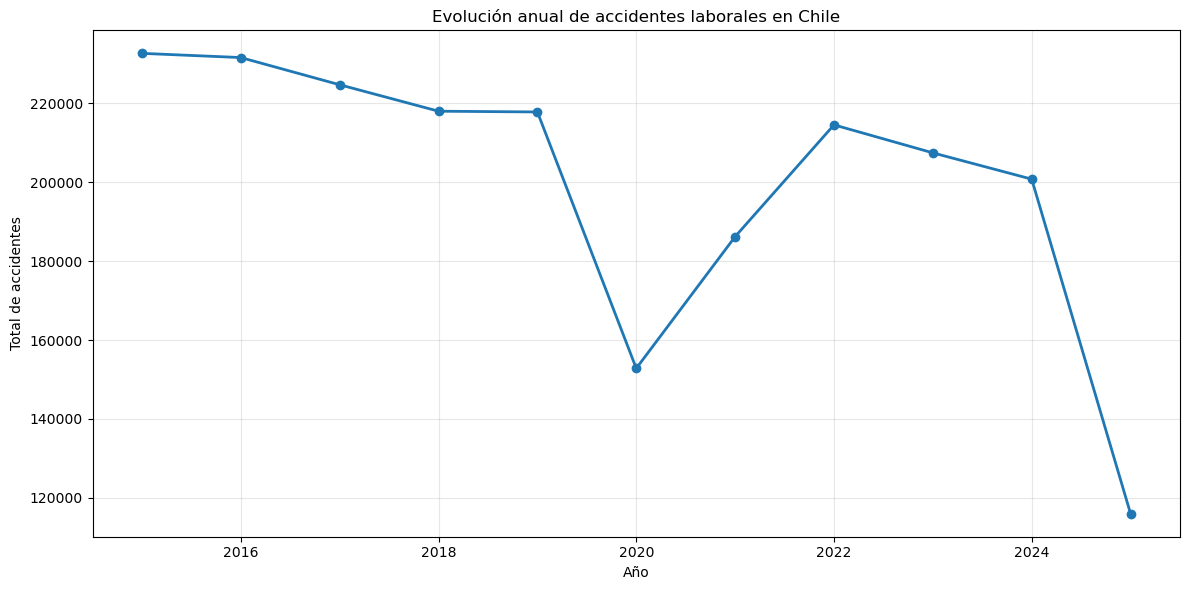

In [34]:
plt.figure(figsize=(12, 6))

plt.plot(
    accidentes_anuales["anio"],
    accidentes_anuales["total_accidentes"],
    marker="o",
    linewidth=2
)

plt.xlabel("Año")
plt.ylabel("Total de accidentes")
plt.title("Evolución anual de accidentes laborales en Chile")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [35]:
meses_por_anio = (
    df_acc
    .groupby("anio")
    .agg(
        meses_con_datos=("mes", "nunique"),
        total_accidentes=("total", "sum")
    )
    .reset_index()
    .sort_values("anio")
)

meses_por_anio

,anio,meses_con_datos,total_accidentes
0,2015,12,232665.0
1,2016,12,231599.0
2,2017,12,224703.0
3,2018,12,218002.0
4,2019,12,217811.0
5,2020,12,152829.0
6,2021,12,186212.0
7,2022,12,214540.0
8,2023,12,207447.0
9,2024,12,200783.0


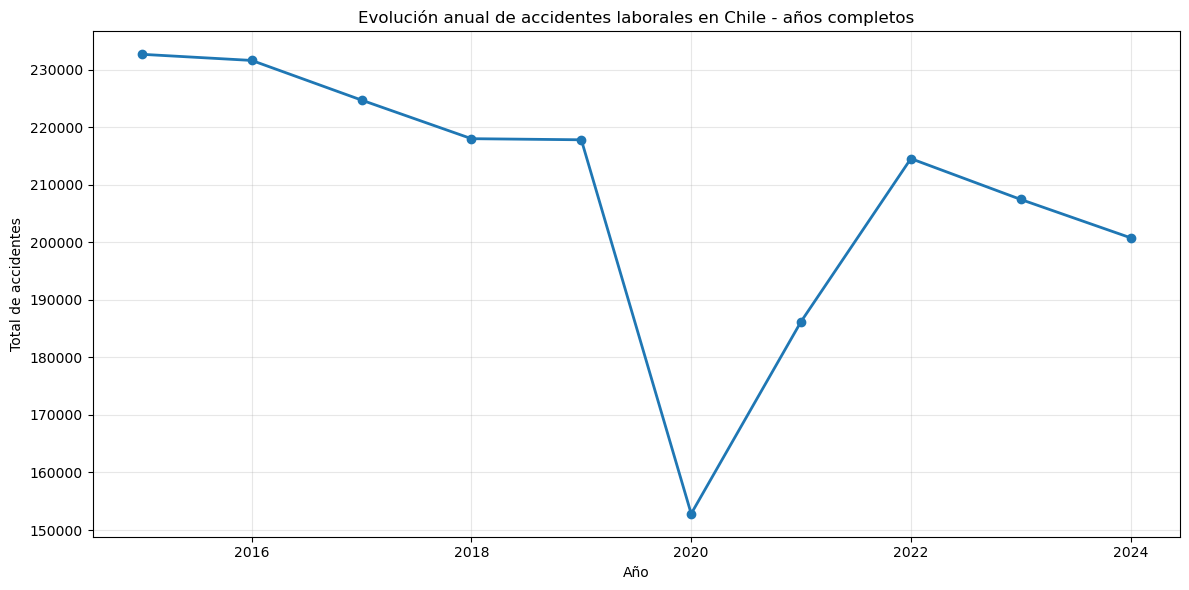

In [36]:
accidentes_anuales_completos = meses_por_anio[
    meses_por_anio["meses_con_datos"] == 12
].copy()

plt.figure(figsize=(12, 6))

plt.plot(
    accidentes_anuales_completos["anio"],
    accidentes_anuales_completos["total_accidentes"],
    marker="o",
    linewidth=2
)

plt.xlabel("Año")
plt.ylabel("Total de accidentes")
plt.title("Evolución anual de accidentes laborales en Chile - años completos")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretación inicial

La evolución anual muestra una disminución progresiva de los accidentes laborales entre 2015 y 2019, seguida de una caída marcada en 2020.

Esta disminución de 2020 podría estar asociada al contexto de la pandemia por COVID-19, periodo en el cual muchas actividades laborales tuvieron restricciones, menor presencialidad, implementación de teletrabajo y cambios en la operación normal de las empresas.

Desde una perspectiva preventiva, esta caída no necesariamente debe interpretarse como una mejora directa en las condiciones de seguridad, sino también como una posible reducción de la exposición presencial a riesgos laborales tradicionales.

Posteriormente se observa una recuperación parcial en 2021 y 2022, para luego volver a presentar una tendencia descendente entre 2023 y 2024.

El año 2025 debe interpretarse con precaución, ya que corresponde a un periodo parcial y no a un año completo. Por esta razón, para analizar tendencias anuales comparables se recomienda trabajar principalmente con años que cuenten con los 12 meses de información disponible.

Este análisis entrega una primera mirada general sobre la evolución de la accidentabilidad laboral en Chile y servirá como base para construir indicadores más precisos, como tasas de accidentabilidad en relación con la cantidad de trabajadores protegidos.
tegidos.

## 4. Accidentes según origen del evento

En esta sección se analiza la distribución anual de accidentes según su origen, diferenciando entre accidentes del trabajo y accidentes de trayecto.

Esta comparación permite observar si ambos tipos de eventos siguen patrones similares o si presentan comportamientos distintos a lo largo del tiempo.

In [37]:
accidentes_origen_anual = (
    df_acc
    .groupby(["anio", "origen"])
    .agg(total_accidentes=("total", "sum"))
    .reset_index()
)

accidentes_origen_anual.head()

,anio,origen,total_accidentes
0,2015,Accidentes de trayecto,52629.0
1,2015,Accidentes del trabajo,180036.0
2,2016,Accidentes de trayecto,54883.0
3,2016,Accidentes del trabajo,176716.0
4,2017,Accidentes de trayecto,54640.0


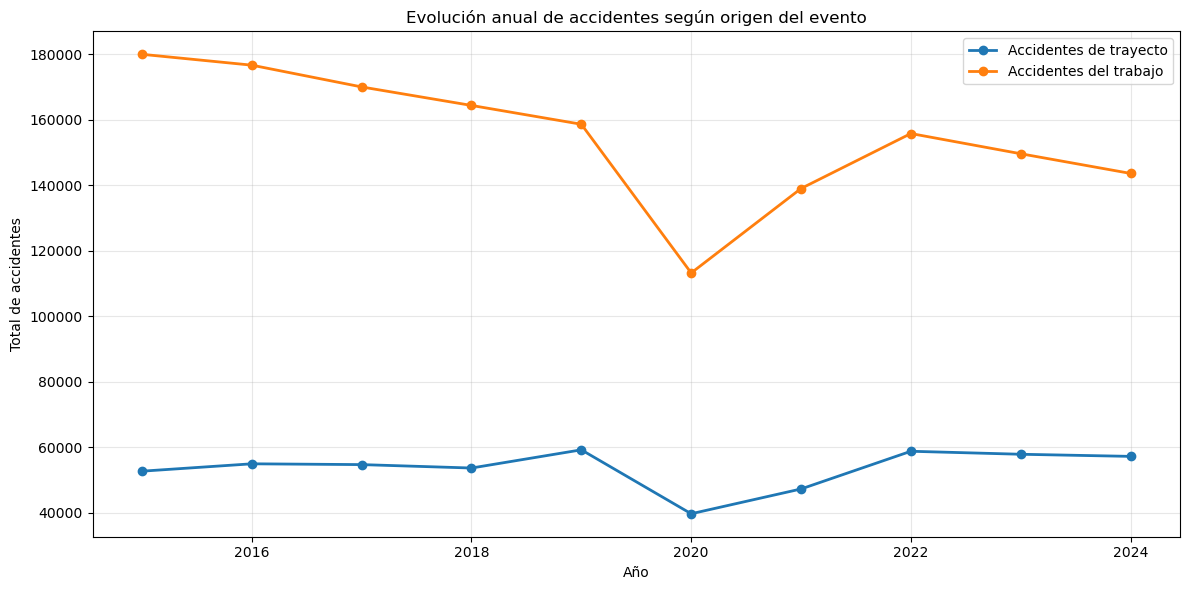

In [38]:
plt.figure(figsize=(12, 6))

for origen in accidentes_origen_anual["origen"].unique():
    datos = accidentes_origen_anual[accidentes_origen_anual["origen"] == origen]
    
    # Considerar solo años completos
    datos = datos[datos["anio"].isin(accidentes_anuales_completos["anio"])]
    
    plt.plot(
        datos["anio"],
        datos["total_accidentes"],
        marker="o",
        linewidth=2,
        label=origen
    )

plt.xlabel("Año")
plt.ylabel("Total de accidentes")
plt.title("Evolución anual de accidentes según origen del evento")

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Interpretación del análisis por origen del accidente

La comparación anual según origen muestra que los accidentes del trabajo concentran la mayor cantidad de eventos durante todo el periodo analizado, en comparación con los accidentes de trayecto.

Entre 2015 y 2019 se observa una disminución gradual de los accidentes del trabajo, mientras que los accidentes de trayecto se mantienen relativamente estables, con una leve variación anual.

En 2020 ambos tipos de accidentes presentan una caída importante. Esta disminución podría estar asociada al contexto de la pandemia por COVID-19, considerando la reducción de presencialidad, restricciones de movilidad, implementación de teletrabajo y cambios en la operación normal de las empresas.

Posteriormente, entre 2021 y 2022 se observa una recuperación parcial, especialmente en los accidentes del trabajo. Sin embargo, hacia 2023 y 2024 vuelve a observarse una tendencia descendente.

Desde una perspectiva preventiva, este análisis permite diferenciar dos dimensiones relevantes: los riesgos propios de la actividad laboral y los riesgos asociados al desplazamiento de las personas trabajadoras. Esta distinción es importante para diseñar estrategias preventivas diferenciadas.


## 5. Participación porcentual según origen del accidente

En esta sección se calcula la participación porcentual de cada tipo de accidente respecto del total anual.

Este análisis permite observar qué proporción corresponde a accidentes del trabajo y qué proporción corresponde a accidentes de trayecto.

In [39]:
total_anual = (
    accidentes_origen_anual
    .groupby("anio")
    .agg(total_anual=("total_accidentes", "sum"))
    .reset_index()
)

accidentes_origen_pct = accidentes_origen_anual.merge(
    total_anual,
    on="anio",
    how="left"
)

accidentes_origen_pct["porcentaje"] = (
    accidentes_origen_pct["total_accidentes"] /
    accidentes_origen_pct["total_anual"] * 100
)

accidentes_origen_pct = accidentes_origen_pct[
    accidentes_origen_pct["anio"].isin(accidentes_anuales_completos["anio"])
].copy()

accidentes_origen_pct.head()

,anio,origen,total_accidentes,total_anual,porcentaje
0,2015,Accidentes de trayecto,52629.0,232665.0,22.620076
1,2015,Accidentes del trabajo,180036.0,232665.0,77.379924
2,2016,Accidentes de trayecto,54883.0,231599.0,23.697425
3,2016,Accidentes del trabajo,176716.0,231599.0,76.302575
4,2017,Accidentes de trayecto,54640.0,224703.0,24.316542


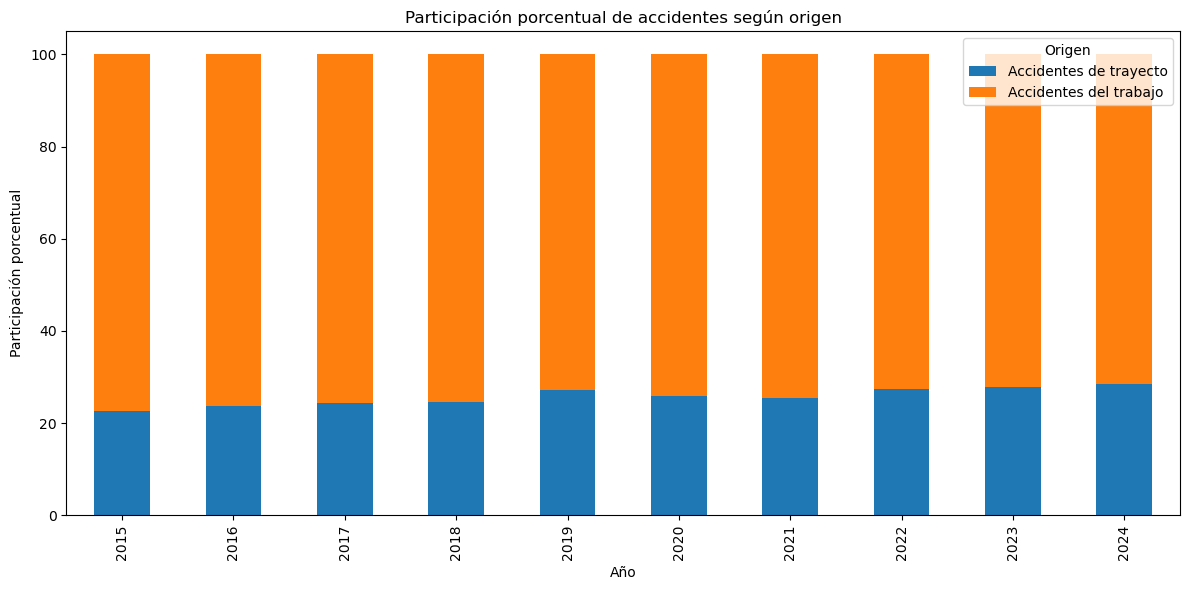

In [40]:
tabla_origen_pct = accidentes_origen_pct.pivot(
    index="anio",
    columns="origen",
    values="porcentaje"
)

tabla_origen_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.xlabel("Año")
plt.ylabel("Participación porcentual")
plt.title("Participación porcentual de accidentes según origen")

plt.legend(title="Origen")
plt.tight_layout()
plt.show()

### Interpretación de la participación porcentual según origen

El análisis porcentual muestra que los accidentes del trabajo representan la mayor proporción del total anual durante todo el periodo analizado.

En términos generales, los accidentes del trabajo concentran cerca de tres cuartas partes de los eventos registrados, mientras que los accidentes de trayecto representan aproximadamente una cuarta parte del total.

Se observa que la participación de los accidentes de trayecto tiende a aumentar levemente hacia los últimos años del periodo, especialmente entre 2022 y 2024. Esto podría indicar que, aunque los accidentes del trabajo siguen siendo predominantes, los eventos asociados al desplazamiento mantienen una relevancia preventiva importante.

Desde una perspectiva de gestión de riesgos, esta información permite diferenciar estrategias preventivas: por una parte, acciones orientadas al control de riesgos propios de la actividad laboral; y por otra, medidas asociadas a seguridad vial, desplazamientos, horarios, rutas y cultura preventiva fuera del lugar físico de trabajo.


## 6. Tasa de accidentabilidad anual

En esta sección se calcula una tasa de accidentabilidad anual, relacionando el total de accidentes registrados con la cantidad promedio de trabajadores protegidos.

Este indicador permite observar la accidentabilidad en términos relativos, es decir, cuántos accidentes se registran por cada 100 trabajadores protegidos.

In [41]:
# Accidentes mensuales
accidentes_mensuales = (
    df_acc
    .groupby(["anio", "mes"])
    .agg(total_accidentes=("total", "sum"))
    .reset_index()
)

# Trabajadores protegidos mensuales
trabajadores_mensuales = (
    df_trab
    .groupby(["anio", "mes"])
    .agg(total_trabajadores=("total", "sum"))
    .reset_index()
)

accidentes_mensuales.head(), trabajadores_mensuales.head()

(   anio  mes  total_accidentes
 0  2015    1           18400.0
 1  2015    2           16362.0
 2  2015    3           21767.0
 3  2015    4           19712.0
 4  2015    5           19540.0,
    anio  mes  total_trabajadores
 0  2015    1           5666789.0
 1  2015    2           5686325.0
 2  2015    3           5621355.0
 3  2015    4           5614759.0
 4  2015    5           5562532.0)

In [42]:
# Resumen anual de accidentes
accidentes_anuales_tasa = (
    accidentes_mensuales
    .groupby("anio")
    .agg(
        total_accidentes=("total_accidentes", "sum"),
        meses_accidentes=("mes", "nunique")
    )
    .reset_index()
)

# Resumen anual de trabajadores protegidos
# Se usa promedio anual porque trabajadores protegidos representa una población mensual.
trabajadores_anuales_tasa = (
    trabajadores_mensuales
    .groupby("anio")
    .agg(
        promedio_trabajadores=("total_trabajadores", "mean"),
        meses_trabajadores=("mes", "nunique")
    )
    .reset_index()
)

indicadores_anuales = accidentes_anuales_tasa.merge(
    trabajadores_anuales_tasa,
    on="anio",
    how="inner"
)

indicadores_anuales["tasa_accidentabilidad"] = (
    indicadores_anuales["total_accidentes"] /
    indicadores_anuales["promedio_trabajadores"] * 100
)

indicadores_anuales

,anio,total_accidentes,meses_accidentes,promedio_trabajadores,meses_trabajadores,tasa_accidentabilidad
0,2015,232665.0,12,5.647982e+06,12,4.119436
1,2016,231599.0,12,5.736429e+06,12,4.037337
2,2017,224703.0,12,5.811317e+06,12,3.866645
3,2018,218002.0,12,6.105926e+06,12,3.570335
4,2019,217811.0,12,6.486105e+06,12,3.358117
5,2020,152829.0,12,6.489576e+06,12,2.354992
6,2021,186212.0,12,6.766276e+06,12,2.752060
7,2022,214540.0,12,7.120738e+06,12,3.012890
8,2023,207447.0,12,7.155456e+06,12,2.899144
9,2024,200783.0,12,7.188135e+06,12,2.793256


In [43]:
indicadores_anuales_completos = indicadores_anuales[
    (indicadores_anuales["meses_accidentes"] == 12) &
    (indicadores_anuales["meses_trabajadores"] == 12)
].copy()

indicadores_anuales_completos

,anio,total_accidentes,meses_accidentes,promedio_trabajadores,meses_trabajadores,tasa_accidentabilidad
0,2015,232665.0,12,5.647982e+06,12,4.119436
1,2016,231599.0,12,5.736429e+06,12,4.037337
2,2017,224703.0,12,5.811317e+06,12,3.866645
3,2018,218002.0,12,6.105926e+06,12,3.570335
4,2019,217811.0,12,6.486105e+06,12,3.358117
5,2020,152829.0,12,6.489576e+06,12,2.354992
6,2021,186212.0,12,6.766276e+06,12,2.752060
7,2022,214540.0,12,7.120738e+06,12,3.012890
8,2023,207447.0,12,7.155456e+06,12,2.899144
9,2024,200783.0,12,7.188135e+06,12,2.793256


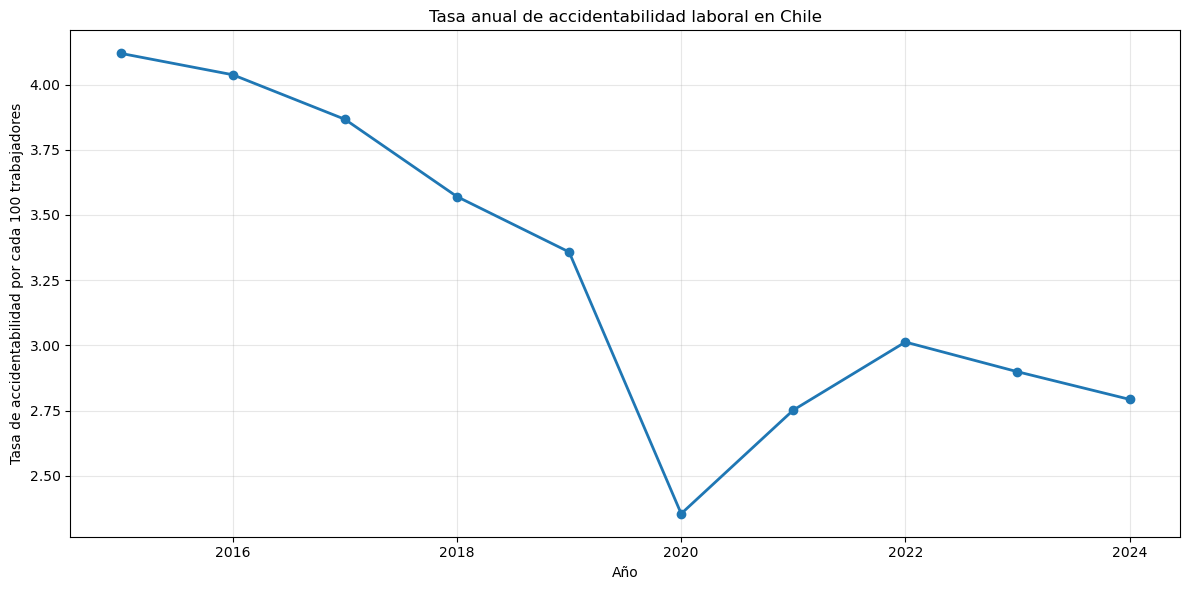

In [44]:
plt.figure(figsize=(12, 6))

plt.plot(
    indicadores_anuales_completos["anio"],
    indicadores_anuales_completos["tasa_accidentabilidad"],
    marker="o",
    linewidth=2
)

plt.xlabel("Año")
plt.ylabel("Tasa de accidentabilidad por cada 100 trabajadores")
plt.title("Tasa anual de accidentabilidad laboral en Chile")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretación de la tasa de accidentabilidad

La tasa de accidentabilidad anual muestra una disminución sostenida entre 2015 y 2019, pasando de valores cercanos a 4 accidentes por cada 100 trabajadores protegidos a valores cercanos a 3,3.

En 2020 se observa una caída marcada de la tasa, lo que podría estar asociado al contexto de la pandemia por COVID-19, con menor presencialidad laboral, restricciones de movilidad, teletrabajo y cambios en la operación normal de diversas actividades económicas.

Posteriormente, entre 2021 y 2022 se aprecia una recuperación parcial de la tasa, aunque sin volver a los niveles observados antes de 2020. Entre 2023 y 2024 vuelve a observarse una disminución moderada.

Este indicador entrega una mirada más precisa que el conteo absoluto de accidentes, ya que relaciona los eventos registrados con la cantidad de trabajadores protegidos. Desde una perspectiva preventiva, permite evaluar la accidentabilidad relativa y apoyar comparaciones entre periodos.
eriodos.

In [45]:
indicadores_anuales_completos[
    ["anio", "total_accidentes", "promedio_trabajadores", "tasa_accidentabilidad", "meses_accidentes", "meses_trabajadores"]
]

,anio,total_accidentes,promedio_trabajadores,tasa_accidentabilidad,meses_accidentes,meses_trabajadores
0,2015,232665.0,5.647982e+06,4.119436,12,12
1,2016,231599.0,5.736429e+06,4.037337,12,12
2,2017,224703.0,5.811317e+06,3.866645,12,12
3,2018,218002.0,6.105926e+06,3.570335,12,12
4,2019,217811.0,6.486105e+06,3.358117,12,12
5,2020,152829.0,6.489576e+06,2.354992,12,12
6,2021,186212.0,6.766276e+06,2.752060,12,12
7,2022,214540.0,7.120738e+06,3.012890,12,12
8,2023,207447.0,7.155456e+06,2.899144,12,12
9,2024,200783.0,7.188135e+06,2.793256,12,12


## 7. Accidentabilidad por región

En esta sección se analiza la distribución de accidentes laborales según región.

El objetivo es identificar qué regiones concentran mayor cantidad de accidentes y comparar estos resultados con la cantidad de trabajadores protegidos para obtener una tasa regional de accidentabilidad.

In [46]:
# Accidentes mensuales por región
accidentes_region_mensual = (
    df_acc[df_acc["anio"].isin(indicadores_anuales_completos["anio"])]
    .groupby(["region", "anio", "mes"])
    .agg(total_accidentes=("total", "sum"))
    .reset_index()
)

# Trabajadores protegidos mensuales por región
trabajadores_region_mensual = (
    df_trab[df_trab["anio"].isin(indicadores_anuales_completos["anio"])]
    .groupby(["region", "anio", "mes"])
    .agg(total_trabajadores=("total", "sum"))
    .reset_index()
)

# Unir accidentes y trabajadores
indicadores_region_mensual = accidentes_region_mensual.merge(
    trabajadores_region_mensual,
    on=["region", "anio", "mes"],
    how="inner"
)

# Resumen regional del periodo completo
indicadores_region = (
    indicadores_region_mensual
    .groupby("region")
    .agg(
        total_accidentes=("total_accidentes", "sum"),
        promedio_trabajadores=("total_trabajadores", "mean")
    )
    .reset_index()
)

# Tasa anualizada aproximada del periodo
# Se divide por cantidad de años para evitar tasa acumulada de 10 años
cantidad_anios = indicadores_anuales_completos["anio"].nunique()

indicadores_region["promedio_accidentes_anual"] = (
    indicadores_region["total_accidentes"] / cantidad_anios
)

indicadores_region["tasa_accidentabilidad"] = (
    indicadores_region["promedio_accidentes_anual"] /
    indicadores_region["promedio_trabajadores"] * 100
)

indicadores_region = indicadores_region.sort_values(
    "total_accidentes",
    ascending=False
)

indicadores_region

,region,total_accidentes,promedio_trabajadores,promedio_accidentes_anual,tasa_accidentabilidad
15,Metropolitana de Santiago,1257461.0,3.809630e+06,125746.1,3.300743
12,Del Biobío,120111.0,4.359867e+05,12011.1,2.754924
6,De Los Lagos,87119.0,2.427649e+05,8711.9,3.588616
14,Del Maule,85305.0,2.643898e+05,8530.5,3.226485
10,De Valparaiso,81838.0,4.276656e+05,8183.8,1.913598
4,De Coquimbo,39012.0,1.536849e+05,3901.2,2.538440
13,Del Libertador Gral. Bdo. O'higgins,37198.0,2.358908e+05,3719.8,1.576916
1,De Antofagasta,36909.0,1.594304e+05,3690.9,2.315055
5,De La Araucania,29988.0,1.864348e+05,2998.8,1.608498
7,De Los Ríos,23446.0,8.072457e+04,2344.6,2.904444


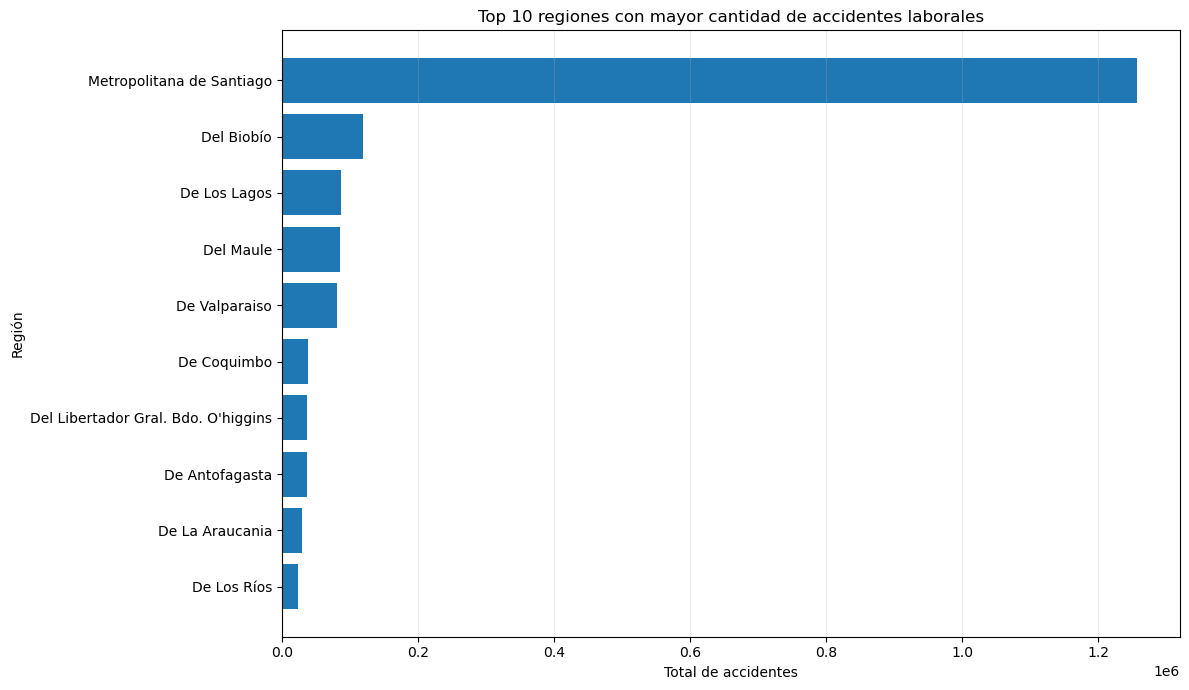

In [47]:
top_regiones_accidentes = indicadores_region.head(10).sort_values("total_accidentes")

plt.figure(figsize=(12, 7))

plt.barh(
    top_regiones_accidentes["region"],
    top_regiones_accidentes["total_accidentes"]
)

plt.xlabel("Total de accidentes")
plt.ylabel("Región")
plt.title("Top 10 regiones con mayor cantidad de accidentes laborales")

plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

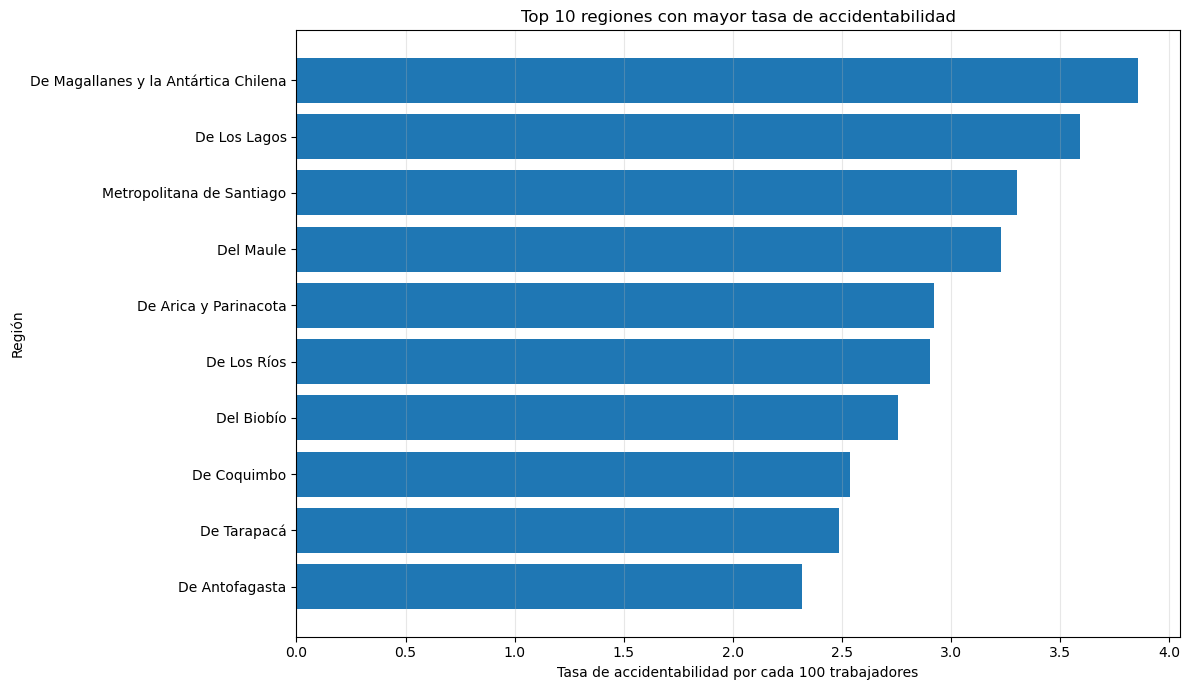

In [48]:
top_regiones_tasa = indicadores_region.sort_values(
    "tasa_accidentabilidad",
    ascending=False
).head(10)

top_regiones_tasa = top_regiones_tasa.sort_values("tasa_accidentabilidad")

plt.figure(figsize=(12, 7))

plt.barh(
    top_regiones_tasa["region"],
    top_regiones_tasa["tasa_accidentabilidad"]
)

plt.xlabel("Tasa de accidentabilidad por cada 100 trabajadores")
plt.ylabel("Región")
plt.title("Top 10 regiones con mayor tasa de accidentabilidad")

plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretación del análisis regional

El análisis regional permite diferenciar entre cantidad absoluta de accidentes y tasa de accidentabilidad.

En términos absolutos, la Región Metropolitana de Santiago concentra la mayor cantidad de accidentes laborales durante el periodo analizado. Esto es esperable, ya que corresponde a una región con alta concentración de trabajadores, empresas y actividad económica.

Sin embargo, al calcular la tasa de accidentabilidad por cada 100 trabajadores protegidos, la lectura cambia. Algunas regiones que no lideran en cantidad total de accidentes presentan tasas más altas, lo que indica una mayor accidentabilidad relativa respecto de su población trabajadora protegida.

Esta diferencia es relevante desde una perspectiva preventiva, ya que permite distinguir entre regiones con mayor volumen de casos y regiones donde el riesgo relativo puede ser más alto. Para la gestión de prevención de riesgos, este tipo de indicador permite priorizar acciones no solo por cantidad de eventos, sino también por exposición relativa de los trabajadores.


## 8. Accidentabilidad por actividad económica

En esta sección se analiza la accidentabilidad laboral según actividad económica CIIU.

El objetivo es identificar qué sectores concentran mayor cantidad de accidentes y cuáles presentan una mayor tasa de accidentabilidad en relación con la cantidad de trabajadores protegidos.

Este análisis permite aportar una mirada sectorial útil para la gestión preventiva, ya que no todas las actividades económicas presentan el mismo nivel de exposición a riesgos laborales.

In [49]:
def acortar_texto(texto, largo=55):
    texto = str(texto)
    return texto if len(texto) <= largo else texto[:largo] + "..."

In [50]:
# Accidentes mensuales por actividad económica
accidentes_actividad_mensual = (
    df_acc[df_acc["anio"].isin(indicadores_anuales_completos["anio"])]
    .groupby(["actividad_economica_ciiu", "anio", "mes"])
    .agg(total_accidentes=("total", "sum"))
    .reset_index()
)

# Trabajadores protegidos mensuales por actividad económica
trabajadores_actividad_mensual = (
    df_trab[df_trab["anio"].isin(indicadores_anuales_completos["anio"])]
    .groupby(["actividad_economica_ciiu", "anio", "mes"])
    .agg(total_trabajadores=("total", "sum"))
    .reset_index()
)

# Unir accidentes y trabajadores
indicadores_actividad_mensual = accidentes_actividad_mensual.merge(
    trabajadores_actividad_mensual,
    on=["actividad_economica_ciiu", "anio", "mes"],
    how="inner"
)

# Resumen por actividad económica
indicadores_actividad = (
    indicadores_actividad_mensual
    .groupby("actividad_economica_ciiu")
    .agg(
        total_accidentes=("total_accidentes", "sum"),
        promedio_trabajadores=("total_trabajadores", "mean")
    )
    .reset_index()
)

cantidad_anios = indicadores_anuales_completos["anio"].nunique()

indicadores_actividad["promedio_accidentes_anual"] = (
    indicadores_actividad["total_accidentes"] / cantidad_anios
)

indicadores_actividad["tasa_accidentabilidad"] = (
    indicadores_actividad["promedio_accidentes_anual"] /
    indicadores_actividad["promedio_trabajadores"] * 100
)

indicadores_actividad = indicadores_actividad.sort_values(
    "total_accidentes",
    ascending=False
)

indicadores_actividad.head(15)

,actividad_economica_ciiu,total_accidentes,promedio_trabajadores,promedio_accidentes_anual,tasa_accidentabilidad
4,Construcción,291805.0,660782.700000,29180.5,4.416051
0,"Actividades inmobiliarias, empresariales y de ...",284937.0,959501.591667,28493.7,2.969636
9,Industrias manufactureras,261022.0,540040.983333,26102.2,4.833374
16,"Transporte, almacenamiento y comunicaciones",180416.0,425086.766667,18041.6,4.244216
2,"Agricultura, ganadería, caza y silvicultura",150336.0,394071.425000,15033.6,3.814943
3,"Comercio, reparación de vehículos y otros",136330.0,828286.125000,13633.0,1.645929
8,Hoteles y restaurantes,122778.0,276369.933333,12277.8,4.442524
5,Enseñanza,101698.0,442841.275000,10169.8,2.296489
14,Servicios sociales y de salud,80633.0,353385.025000,8063.3,2.281732
1,Administración publica y defensa - planes de s...,52142.0,414358.145833,5214.2,1.258380


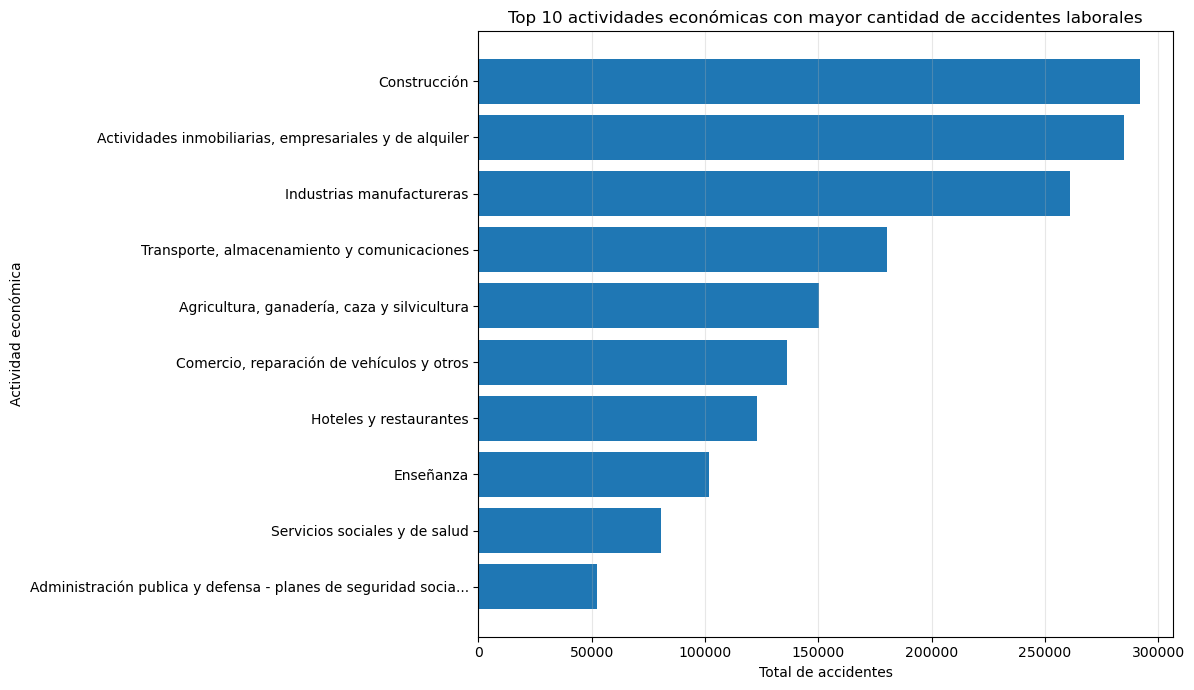

In [51]:
top_actividades_accidentes = indicadores_actividad.head(10).copy()
top_actividades_accidentes["actividad_corta"] = top_actividades_accidentes["actividad_economica_ciiu"].apply(
    lambda x: acortar_texto(x, 60)
)

top_actividades_accidentes = top_actividades_accidentes.sort_values("total_accidentes")

plt.figure(figsize=(12, 7))

plt.barh(
    top_actividades_accidentes["actividad_corta"],
    top_actividades_accidentes["total_accidentes"]
)

plt.xlabel("Total de accidentes")
plt.ylabel("Actividad económica")
plt.title("Top 10 actividades económicas con mayor cantidad de accidentes laborales")

plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

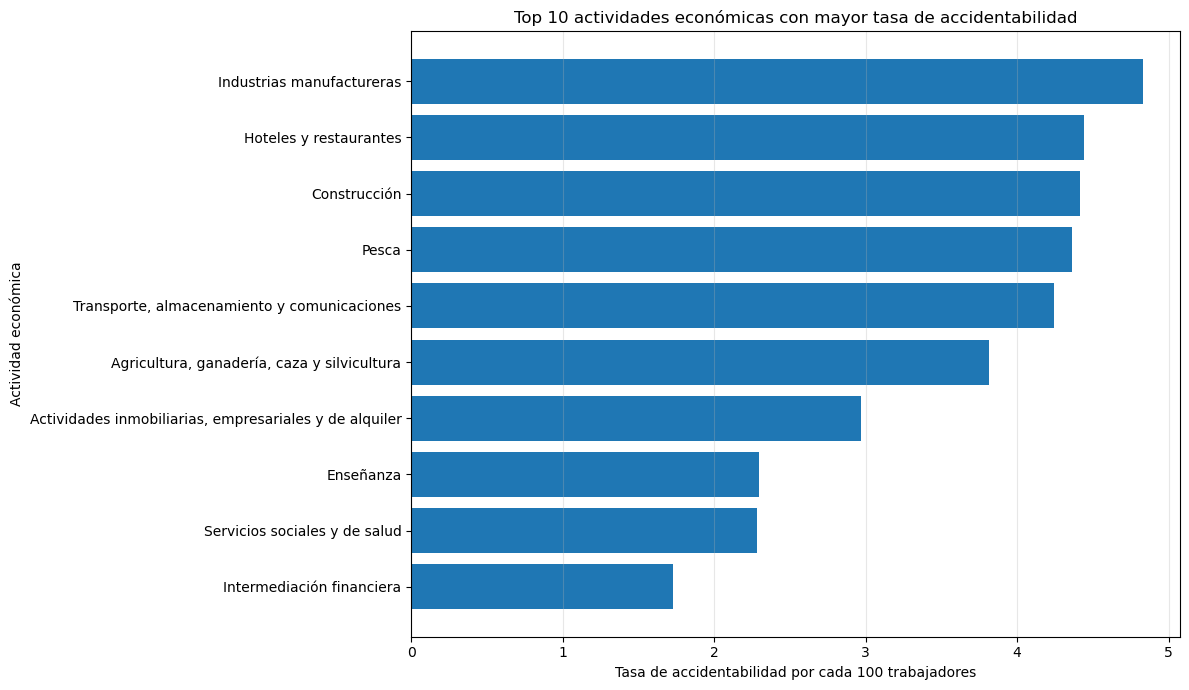

In [52]:
top_actividades_tasa = indicadores_actividad.sort_values(
    "tasa_accidentabilidad",
    ascending=False
).head(10).copy()

top_actividades_tasa["actividad_corta"] = top_actividades_tasa["actividad_economica_ciiu"].apply(
    lambda x: acortar_texto(x, 60)
)

top_actividades_tasa = top_actividades_tasa.sort_values("tasa_accidentabilidad")

plt.figure(figsize=(12, 7))

plt.barh(
    top_actividades_tasa["actividad_corta"],
    top_actividades_tasa["tasa_accidentabilidad"]
)

plt.xlabel("Tasa de accidentabilidad por cada 100 trabajadores")
plt.ylabel("Actividad económica")
plt.title("Top 10 actividades económicas con mayor tasa de accidentabilidad")

plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretación del análisis por actividad económica

El análisis por actividad económica permite distinguir entre sectores que concentran mayor cantidad absoluta de accidentes y sectores que presentan una mayor tasa de accidentabilidad relativa.

En términos absolutos, actividades como comercio, construcción, actividades administrativas, industria manufacturera y transporte concentran una parte importante de los accidentes laborales registrados. Esto puede estar asociado al tamaño de estos sectores, la cantidad de trabajadores protegidos y el nivel de actividad operacional.

Sin embargo, al observar la tasa de accidentabilidad por cada 100 trabajadores protegidos, la lectura cambia. Sectores como industria manufacturera, construcción, pesca, transporte y agricultura presentan una mayor accidentabilidad relativa, lo que sugiere una mayor exposición a riesgos laborales en relación con su población trabajadora.

Desde una perspectiva preventiva, esta diferencia es relevante porque permite evitar conclusiones basadas solo en volumen. Un sector puede registrar muchos accidentes por tener una gran cantidad de trabajadores, mientras que otro puede presentar una tasa más alta y requerir mayor atención preventiva proporcional.

Este análisis permite priorizar sectores económicos donde podrían fortalecerse acciones preventivas, programas de capacitación, fiscalización, control operacional y seguimiento de indicadores de seguridad laboral.


## 9. Accidentabilidad por organismo administrador

En esta sección se analiza la distribución de accidentes laborales según organismo administrador.

El objetivo es observar qué organismos concentran mayor cantidad de accidentes registrados y cómo se comporta la accidentabilidad relativa al considerar la cantidad de trabajadores protegidos.

Este análisis permite complementar la mirada preventiva desde la perspectiva de cobertura del seguro laboral y gestión institucional de la accidentabilidad.

In [53]:
# Accidentes mensuales por organismo administrador
accidentes_organismo_mensual = (
    df_acc[df_acc["anio"].isin(indicadores_anuales_completos["anio"])]
    .groupby(["organismo_administrador", "anio", "mes"])
    .agg(total_accidentes=("total", "sum"))
    .reset_index()
)

# Trabajadores protegidos mensuales por organismo administrador
trabajadores_organismo_mensual = (
    df_trab[df_trab["anio"].isin(indicadores_anuales_completos["anio"])]
    .groupby(["organismoadministrador", "anio", "mes"])
    .agg(total_trabajadores=("total", "sum"))
    .reset_index()
)

trabajadores_organismo_mensual = trabajadores_organismo_mensual.rename(
    columns={"organismoadministrador": "organismo_administrador"}
)

# Unión de ambas bases
indicadores_organismo_mensual = accidentes_organismo_mensual.merge(
    trabajadores_organismo_mensual,
    on=["organismo_administrador", "anio", "mes"],
    how="inner"
)

# Resumen por organismo administrador
indicadores_organismo = (
    indicadores_organismo_mensual
    .groupby("organismo_administrador")
    .agg(
        total_accidentes=("total_accidentes", "sum"),
        promedio_trabajadores=("total_trabajadores", "mean")
    )
    .reset_index()
)

cantidad_anios = indicadores_anuales_completos["anio"].nunique()

indicadores_organismo["promedio_accidentes_anual"] = (
    indicadores_organismo["total_accidentes"] / cantidad_anios
)

indicadores_organismo["tasa_accidentabilidad"] = (
    indicadores_organismo["promedio_accidentes_anual"] /
    indicadores_organismo["promedio_trabajadores"] * 100
)

indicadores_organismo = indicadores_organismo.sort_values(
    "total_accidentes",
    ascending=False
)

indicadores_organismo

,organismo_administrador,total_accidentes,promedio_trabajadores,promedio_accidentes_anual,tasa_accidentabilidad
0,A.CH.S.,917632.0,2.623989e+06,91763.2,3.497088
2,MUSEG,903017.0,2.119227e+06,90301.7,4.261068
1,I.S.T.,265942.0,5.486258e+05,26594.2,4.847420


In [54]:
df_trab.columns

Index(['tamano_de_empresa', 'periodo', 'actividad_economica_ciiu', 'region',
       'periodoano', 'organismoadministrador', 'mujer', 'hombre',
       'sin_informacion', 'total', 'fecha', 'anio', 'mes'],
      dtype='object')

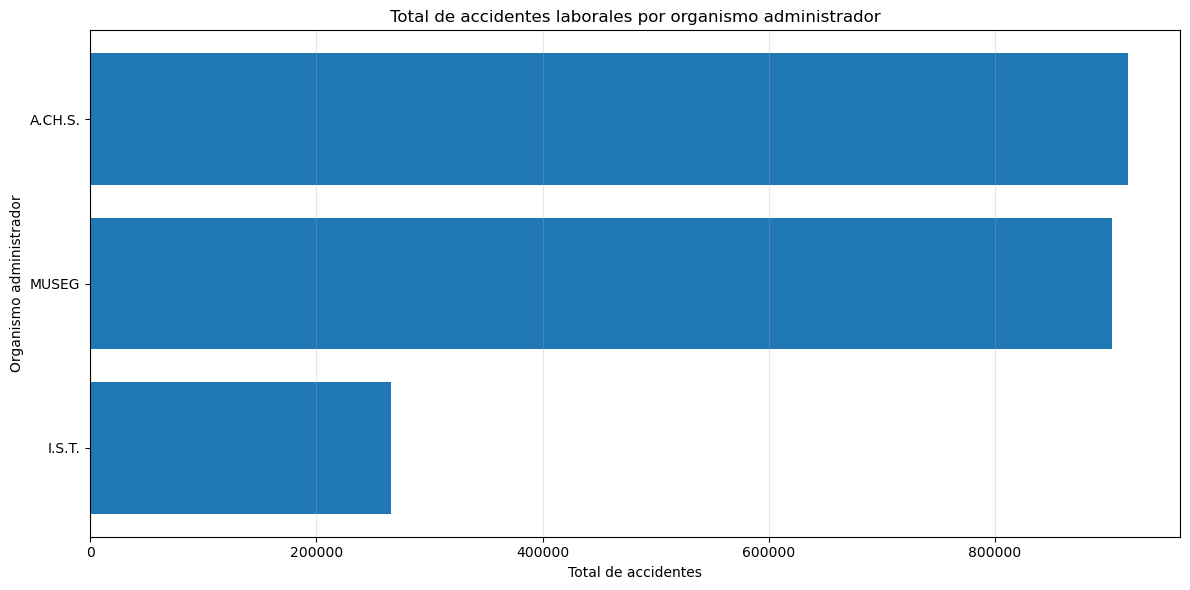

In [55]:
organismo_total = indicadores_organismo.sort_values("total_accidentes")

plt.figure(figsize=(12, 6))

plt.barh(
    organismo_total["organismo_administrador"],
    organismo_total["total_accidentes"]
)

plt.xlabel("Total de accidentes")
plt.ylabel("Organismo administrador")
plt.title("Total de accidentes laborales por organismo administrador")

plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

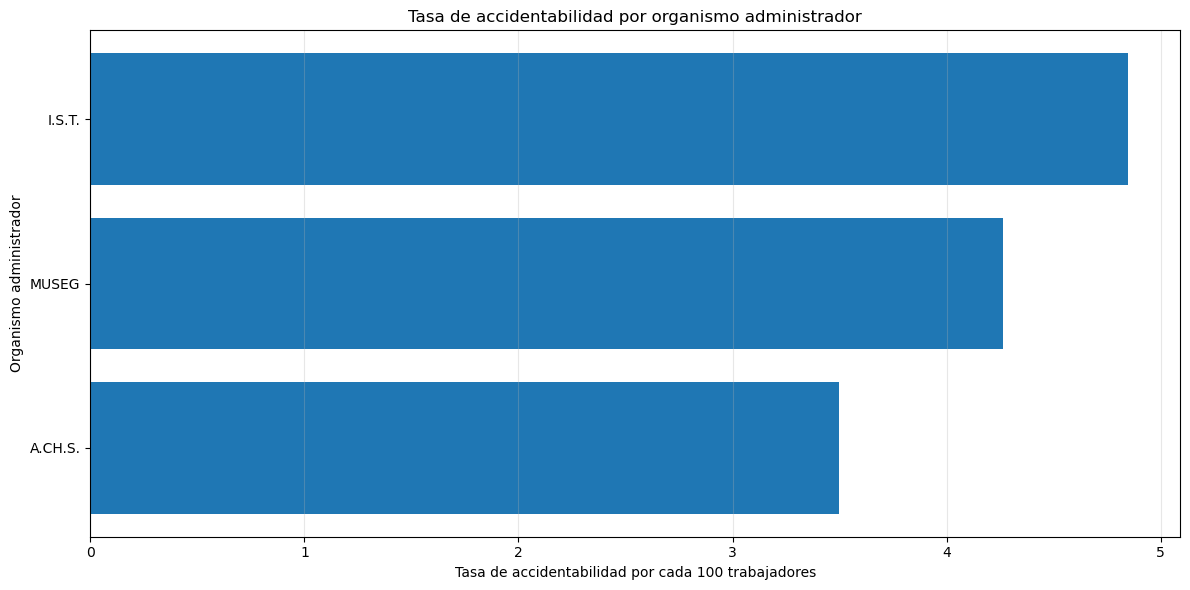

In [56]:
organismo_tasa = indicadores_organismo.sort_values("tasa_accidentabilidad")

plt.figure(figsize=(12, 6))

plt.barh(
    organismo_tasa["organismo_administrador"],
    organismo_tasa["tasa_accidentabilidad"]
)

plt.xlabel("Tasa de accidentabilidad por cada 100 trabajadores")
plt.ylabel("Organismo administrador")
plt.title("Tasa de accidentabilidad por organismo administrador")

plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretación del análisis por organismo administrador

El análisis por organismo administrador permite comparar tanto el volumen total de accidentes como la tasa de accidentabilidad relativa.

En términos absolutos, ACHS y Mutual concentran la mayor cantidad de accidentes laborales registrados durante el periodo analizado. Esto puede estar asociado a una mayor cantidad de trabajadores protegidos, mayor cobertura de empresas afiliadas y mayor participación dentro del sistema.

Sin embargo, al observar la tasa de accidentabilidad por cada 100 trabajadores protegidos, la lectura cambia. El ISL presenta una tasa relativa más alta, lo que indica que, proporcionalmente a su población protegida, registra una mayor accidentabilidad en comparación con los otros organismos analizados.

Esta diferencia es relevante desde una perspectiva preventiva, ya que permite distinguir entre organismos con mayor volumen de casos y organismos con mayor accidentabilidad relativa. No obstante, esta comparación debe interpretarse con cautela, ya que la tasa puede estar influenciada por la composición de empresas afiliadas, sectores económicos, tamaño de empresas, distribución regional y características de los trabajadores protegidos.

Este análisis refuerza la importancia de utilizar indicadores relativos y no solo conteos absolutos para apoyar la toma de decisiones en prevención de riesgos laborales.


## 10. Accidentabilidad según forma del accidente

En esta sección se analiza la distribución de accidentes laborales según la forma en que ocurrió el evento.

El objetivo es identificar los mecanismos de accidente más frecuentes, lo que permite orientar acciones preventivas específicas, como capacitación, control operacional, mejoras en procedimientos, uso de elementos de protección personal y revisión de condiciones de trabajo.


In [57]:
# Accidentes según forma del accidente
accidentes_forma = (
    df_acc[df_acc["anio"].isin(indicadores_anuales_completos["anio"])]
    .groupby("forma_del_accidente")
    .agg(total_accidentes=("total", "sum"))
    .reset_index()
    .sort_values("total_accidentes", ascending=False)
)

accidentes_forma.head(15)

,forma_del_accidente,total_accidentes
14,Sin Información,1678361.0
4,Caída de personas,136306.0
0,Accidentes que involucran vehículos,49321.0
9,Objetos corto-punzantes,48024.0
8,Golpes por o contra objetos,32953.0
15,Sobreesfuerzo y falsos movimientos,27631.0
12,Pisadas (tropiezos sin caídas),23077.0
10,Otras formas de accidentes,19750.0
3,Atrapamientos o amputaciones,19004.0
2,Amenazas o agresiones de personas,18891.0


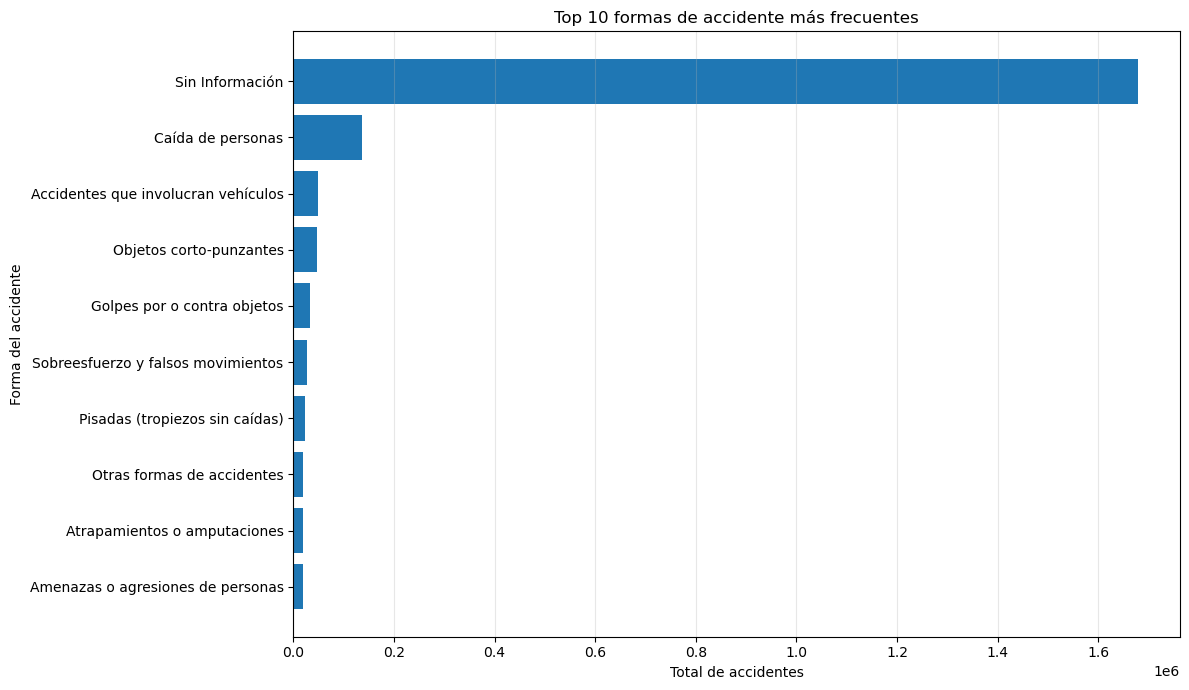

In [58]:
top_formas_accidente = accidentes_forma.head(10).copy()
top_formas_accidente["forma_corta"] = top_formas_accidente["forma_del_accidente"].apply(
    lambda x: acortar_texto(x, 60)
)

top_formas_accidente = top_formas_accidente.sort_values("total_accidentes")

plt.figure(figsize=(12, 7))

plt.barh(
    top_formas_accidente["forma_corta"],
    top_formas_accidente["total_accidentes"]
)

plt.xlabel("Total de accidentes")
plt.ylabel("Forma del accidente")
plt.title("Top 10 formas de accidente más frecuentes")

plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretación inicial

El análisis muestra que una parte muy importante de los registros se encuentra clasificada como “Sin Información”, lo que limita la interpretación técnica de la forma específica en que ocurrieron los accidentes.

Este resultado es relevante desde una perspectiva de gestión, ya que evidencia una oportunidad de mejora en la calidad del registro y clasificación de los accidentes laborales.

Al excluir los registros sin información, es posible observar con mayor claridad las formas de accidente más frecuentes, tales como caídas de personas, accidentes que involucran vehículos, objetos corto-punzantes, golpes contra objetos, sobreesfuerzos y pisadas o tropiezos.

Para un análisis preventivo más preciso, resulta recomendable mejorar la completitud de los datos y fortalecer la clasificación de los mecanismos de accidente.


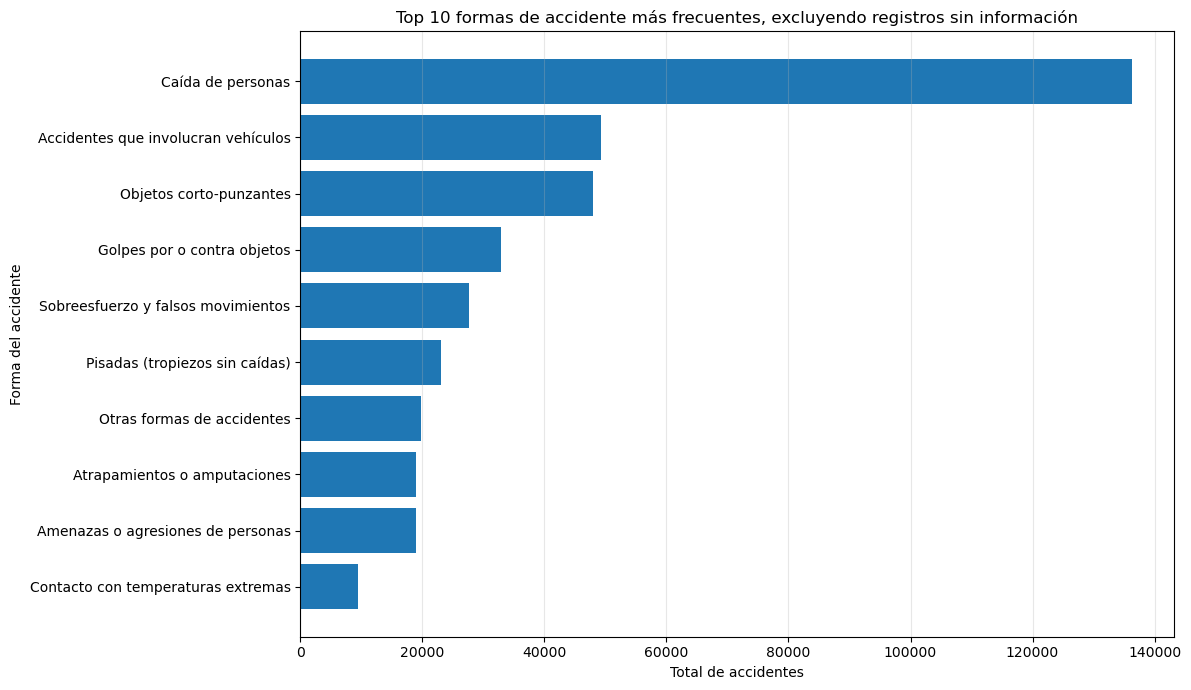

In [59]:
accidentes_forma_filtrado = accidentes_forma[
    accidentes_forma["forma_del_accidente"].str.lower() != "sin información"
].copy()

top_formas_accidente_filtrado = accidentes_forma_filtrado.head(10).copy()

top_formas_accidente_filtrado["forma_corta"] = top_formas_accidente_filtrado["forma_del_accidente"].apply(
    lambda x: acortar_texto(x, 60)
)

top_formas_accidente_filtrado = top_formas_accidente_filtrado.sort_values("total_accidentes")

plt.figure(figsize=(12, 7))

plt.barh(
    top_formas_accidente_filtrado["forma_corta"],
    top_formas_accidente_filtrado["total_accidentes"]
)

plt.xlabel("Total de accidentes")
plt.ylabel("Forma del accidente")
plt.title("Top 10 formas de accidente más frecuentes, excluyendo registros sin información")

plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretación de las formas de accidente más frecuentes

Al excluir los registros clasificados como “Sin Información”, se observa con mayor claridad la distribución de las formas de accidente más frecuentes.

La categoría predominante corresponde a la **caída de personas**, lo que sugiere una alta relevancia de riesgos asociados al desplazamiento, condiciones del entorno de trabajo, orden y limpieza, y eventualmente trabajo en altura.

En segundo nivel aparecen los **accidentes que involucran vehículos**, los **objetos corto-punzantes**, los **golpes por o contra objetos** y los **sobreesfuerzos o falsos movimientos**, lo que refleja una importante presencia de riesgos operacionales y mecánicos.

En conjunto, estos resultados permiten identificar focos preventivos prioritarios y orientar futuras medidas de control, capacitación y gestión del riesgo hacia los mecanismos de accidente con mayor recurrencia.

## 11. Accidentabilidad según parte del cuerpo afectada

En esta sección se analiza la distribución de accidentes laborales según la parte del cuerpo afectada.

El objetivo es identificar las zonas corporales más comprometidas en los accidentes registrados, lo que permite orientar acciones preventivas relacionadas con procedimientos de trabajo, ergonomía, uso de elementos de protección personal, capacitación y control de riesgos operacionales.


In [60]:
# Accidentes según parte del cuerpo afectada
accidentes_parte_cuerpo = (
    df_acc[df_acc["anio"].isin(indicadores_anuales_completos["anio"])]
    .groupby("parte_del_cuerpo")
    .agg(total_accidentes=("total", "sum"))
    .reset_index()
    .sort_values("total_accidentes", ascending=False)
)

accidentes_parte_cuerpo.head(15)

,parte_del_cuerpo,total_accidentes
7,Sin información,1277610.0
4,Miembros superiores,296805.0
3,Miembros inferiores,258902.0
0,Cabeza,127793.0
9,Torso,53461.0
2,Espalda,26878.0
8,Todo el cuerpo o sitios múltiples,23015.0
1,Cuello,19291.0
5,Otras partes del cuerpo,2223.0
6,Parte no especificada,613.0


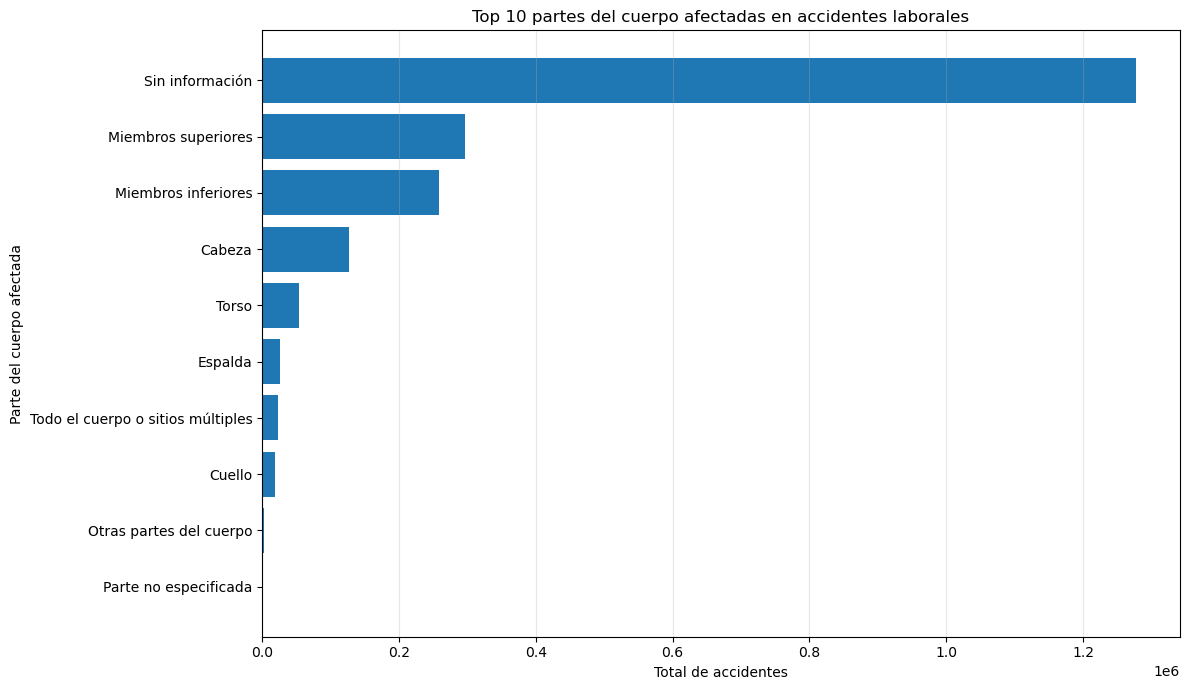

In [61]:
top_partes_cuerpo = accidentes_parte_cuerpo.head(10).copy()

top_partes_cuerpo["parte_corta"] = top_partes_cuerpo["parte_del_cuerpo"].apply(
    lambda x: acortar_texto(x, 60)
)

top_partes_cuerpo = top_partes_cuerpo.sort_values("total_accidentes")

plt.figure(figsize=(12, 7))

plt.barh(
    top_partes_cuerpo["parte_corta"],
    top_partes_cuerpo["total_accidentes"]
)

plt.xlabel("Total de accidentes")
plt.ylabel("Parte del cuerpo afectada")
plt.title("Top 10 partes del cuerpo afectadas en accidentes laborales")

plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

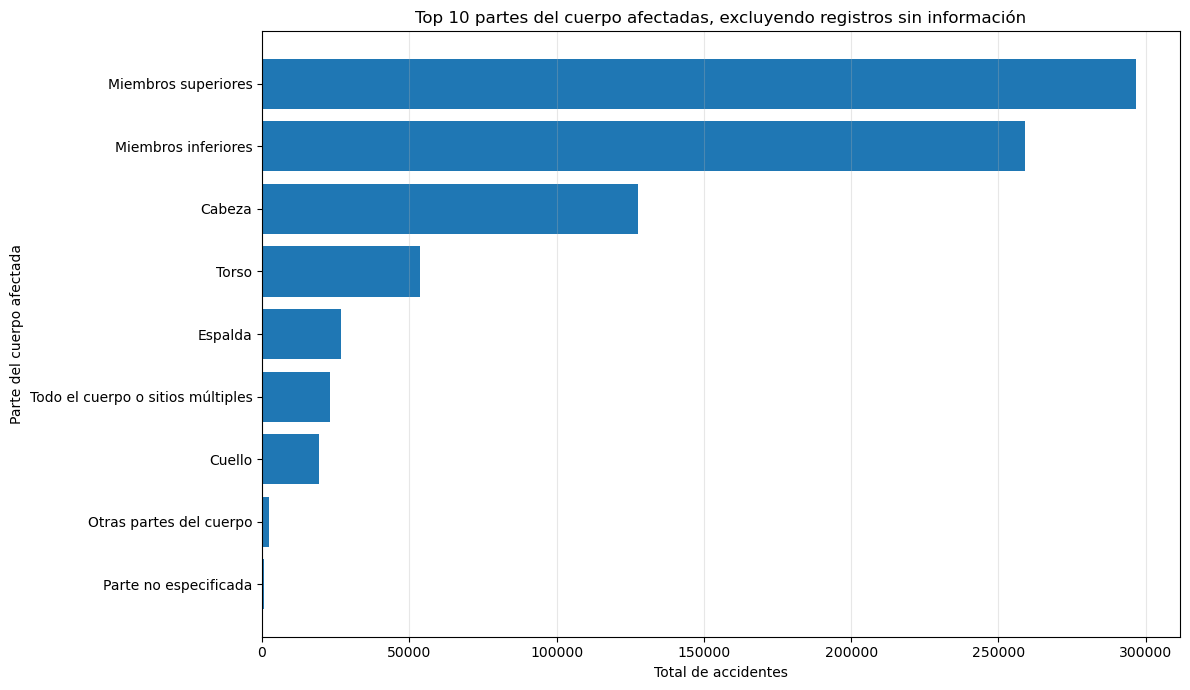

In [62]:
accidentes_parte_cuerpo_filtrado = accidentes_parte_cuerpo[
    accidentes_parte_cuerpo["parte_del_cuerpo"].str.lower() != "sin información"
].copy()

top_partes_cuerpo_filtrado = accidentes_parte_cuerpo_filtrado.head(10).copy()

top_partes_cuerpo_filtrado["parte_corta"] = top_partes_cuerpo_filtrado["parte_del_cuerpo"].apply(
    lambda x: acortar_texto(x, 60)
)

top_partes_cuerpo_filtrado = top_partes_cuerpo_filtrado.sort_values("total_accidentes")

plt.figure(figsize=(12, 7))

plt.barh(
    top_partes_cuerpo_filtrado["parte_corta"],
    top_partes_cuerpo_filtrado["total_accidentes"]
)

plt.xlabel("Total de accidentes")
plt.ylabel("Parte del cuerpo afectada")
plt.title("Top 10 partes del cuerpo afectadas, excluyendo registros sin información")

plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretación

Al excluir los registros sin información, se observa que las partes del cuerpo más afectadas en los accidentes laborales corresponden principalmente a los miembros superiores y miembros inferiores, seguidos por cabeza y tórax.

Este resultado sugiere que una proporción importante de los accidentes está asociada a actividades operativas, manipulación de herramientas o materiales, desplazamientos y contacto con objetos o superficies, lo que expone especialmente extremidades y zonas corporales de alta utilización en el trabajo diario.

Desde una perspectiva preventiva, estos hallazgos orientan la necesidad de reforzar medidas de control relacionadas con procedimientos seguros de trabajo, orden y limpieza, ergonomía, protección de manos y pies, uso adecuado de elementos de protección personal y capacitación en tareas de riesgo.

## 12. Accidentabilidad según agente del accidente

En esta sección se analiza la distribución de accidentes laborales según el agente asociado al evento.

El objetivo es identificar los elementos, condiciones u objetos que aparecen con mayor frecuencia en los accidentes registrados, lo que permite orientar medidas preventivas relacionadas con control operacional, mantenimiento, señalización, procedimientos de trabajo, capacitación y uso adecuado de elementos de protección personal.


In [63]:
# Accidentes según agente del accidente
accidentes_agente = (
    df_acc[df_acc["anio"].isin(indicadores_anuales_completos["anio"])]
    .groupby("agente_del_accidente")
    .agg(total_accidentes=("total", "sum"))
    .reset_index()
    .sort_values("total_accidentes", ascending=False)
)

accidentes_agente.head(15)

,agente_del_accidente,total_accidentes
13,Sin Información,1679014.0
5,Herramientas y aparatos,106367.0
8,Medios de transporte terreste,73919.0
6,Materiales y sustancias,45406.0
12,Personas,39649.0
0,Ambiente de trabajo exterior,37221.0
1,Ambiente de trabajo interior,37010.0
9,Máquinas,29815.0
10,Otros agentes,17535.0
7,Medios de transporte acuáticos y aéreos,12057.0


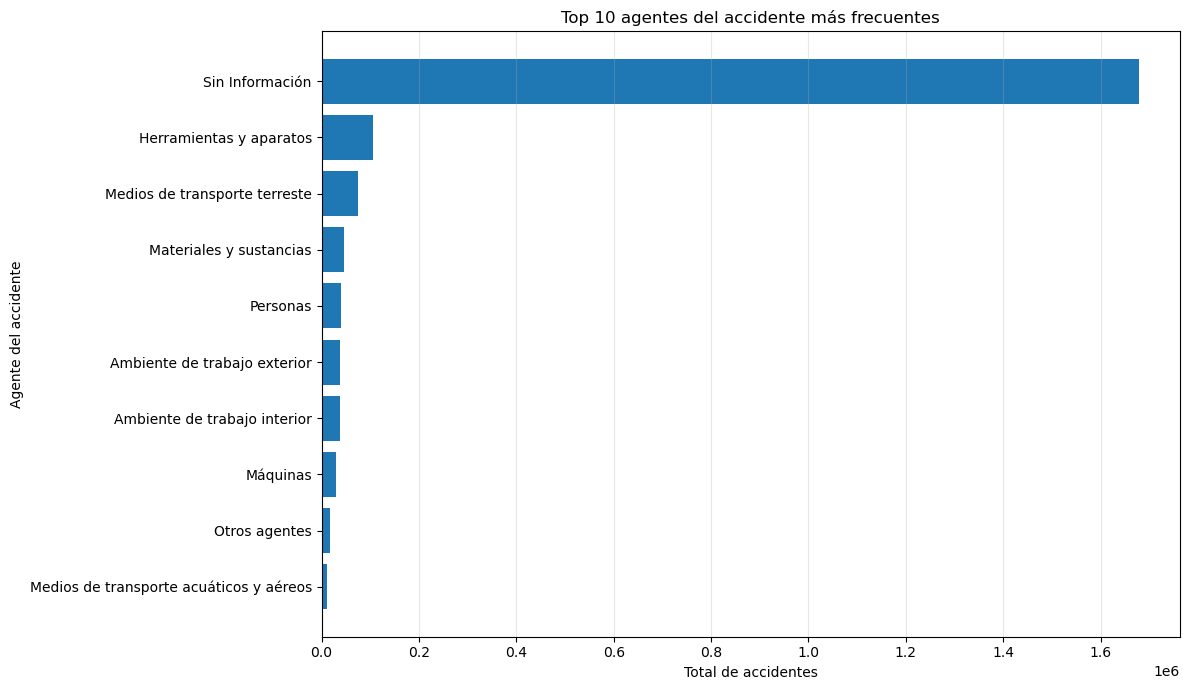

In [64]:
top_agentes = accidentes_agente.head(10).copy()

top_agentes["agente_corto"] = top_agentes["agente_del_accidente"].apply(
    lambda x: acortar_texto(x, 60)
)

top_agentes = top_agentes.sort_values("total_accidentes")

plt.figure(figsize=(12, 7))

plt.barh(
    top_agentes["agente_corto"],
    top_agentes["total_accidentes"]
)

plt.xlabel("Total de accidentes")
plt.ylabel("Agente del accidente")
plt.title("Top 10 agentes del accidente más frecuentes")

plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

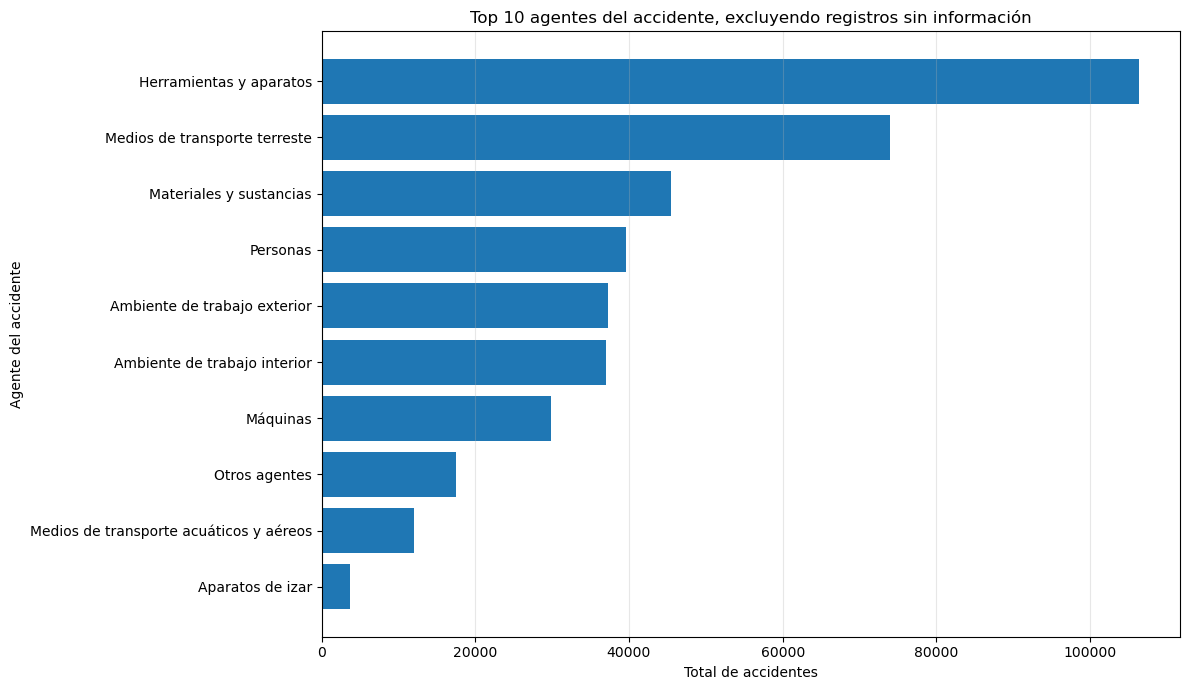

In [65]:
accidentes_agente_filtrado = accidentes_agente[
    accidentes_agente["agente_del_accidente"].str.lower() != "sin información"
].copy()

top_agentes_filtrado = accidentes_agente_filtrado.head(10).copy()

top_agentes_filtrado["agente_corto"] = top_agentes_filtrado["agente_del_accidente"].apply(
    lambda x: acortar_texto(x, 60)
)

top_agentes_filtrado = top_agentes_filtrado.sort_values("total_accidentes")

plt.figure(figsize=(12, 7))

plt.barh(
    top_agentes_filtrado["agente_corto"],
    top_agentes_filtrado["total_accidentes"]
)

plt.xlabel("Total de accidentes")
plt.ylabel("Agente del accidente")
plt.title("Top 10 agentes del accidente, excluyendo registros sin información")

plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretación del análisis según agente del accidente

Al excluir los registros clasificados como “Sin Información”, se observa que los agentes del accidente más frecuentes corresponden principalmente a herramientas y aparatos, medios de transporte terrestre, materiales y sustancias, vehículos, ambientes de trabajo y máquinas.

Estos resultados sugieren que una parte importante de la accidentabilidad laboral está asociada a tareas operacionales, manipulación de herramientas, interacción con equipos, desplazamientos, transporte y exposición a condiciones del entorno de trabajo.

Desde una perspectiva preventiva, este análisis permite orientar medidas de control hacia el uso seguro de herramientas y equipos, mantenimiento preventivo, segregación de tránsito peatonal y vehicular, control de materiales, orden y limpieza, señalización, capacitación operacional y supervisión de tareas críticas.

Además, la alta presencia de registros sin información en el análisis original evidencia una oportunidad de mejora en la calidad del registro de accidentes, especialmente en la clasificación del agente asociado al evento.


## 13. Accidentabilidad según tamaño de empresa

En esta sección se analiza la accidentabilidad laboral según el tamaño de empresa.

El objetivo es observar cómo se distribuyen los accidentes entre distintos tamaños de empresa y comparar el volumen total de accidentes con la tasa de accidentabilidad relativa respecto de la cantidad de trabajadores protegidos.

Este análisis permite identificar si ciertos tamaños de empresa presentan una mayor concentración de accidentes o una mayor accidentabilidad proporcional, lo que puede orientar estrategias preventivas diferenciadas.


In [66]:
# Accidentes mensuales por tamaño de empresa
accidentes_tamano_mensual = (
    df_acc[df_acc["anio"].isin(indicadores_anuales_completos["anio"])]
    .groupby(["tamano_de_empresa", "anio", "mes"])
    .agg(total_accidentes=("total", "sum"))
    .reset_index()
)

# Trabajadores protegidos mensuales por tamaño de empresa
trabajadores_tamano_mensual = (
    df_trab[df_trab["anio"].isin(indicadores_anuales_completos["anio"])]
    .groupby(["tamano_de_empresa", "anio", "mes"])
    .agg(total_trabajadores=("total", "sum"))
    .reset_index()
)

# Unión de ambas bases
indicadores_tamano_mensual = accidentes_tamano_mensual.merge(
    trabajadores_tamano_mensual,
    on=["tamano_de_empresa", "anio", "mes"],
    how="inner"
)

# Resumen por tamaño de empresa
indicadores_tamano = (
    indicadores_tamano_mensual
    .groupby("tamano_de_empresa")
    .agg(
        total_accidentes=("total_accidentes", "sum"),
        promedio_trabajadores=("total_trabajadores", "mean")
    )
    .reset_index()
)

cantidad_anios = indicadores_anuales_completos["anio"].nunique()

indicadores_tamano["promedio_accidentes_anual"] = (
    indicadores_tamano["total_accidentes"] / cantidad_anios
)

indicadores_tamano["tasa_accidentabilidad"] = (
    indicadores_tamano["promedio_accidentes_anual"] /
    indicadores_tamano["promedio_trabajadores"] * 100
)

indicadores_tamano = indicadores_tamano.sort_values(
    "total_accidentes",
    ascending=False
)

indicadores_tamano

,tamano_de_empresa,total_accidentes,promedio_trabajadores,promedio_accidentes_anual,tasa_accidentabilidad
2,"""1000 y más""",255244.0,1.621189e+06,25524.4,1.574425
4,"""200-499""",124413.0,6.825353e+05,12441.3,1.822807
6,"""50-100""",94189.0,4.766402e+05,9418.9,1.976103
1,"""10-25""",93073.0,5.730478e+05,9307.3,1.624175
3,"""101-199""",91601.0,4.710325e+05,9160.1,1.944685
0,"""1-9""",83485.0,9.999800e+05,8348.5,0.834867
7,"""500-999""",83452.0,5.421940e+05,8345.2,1.539154
5,"""26-49""",78893.0,4.122607e+05,7889.3,1.913668
8,"""Sin información""",2619.0,4.653415e+04,261.9,0.562813


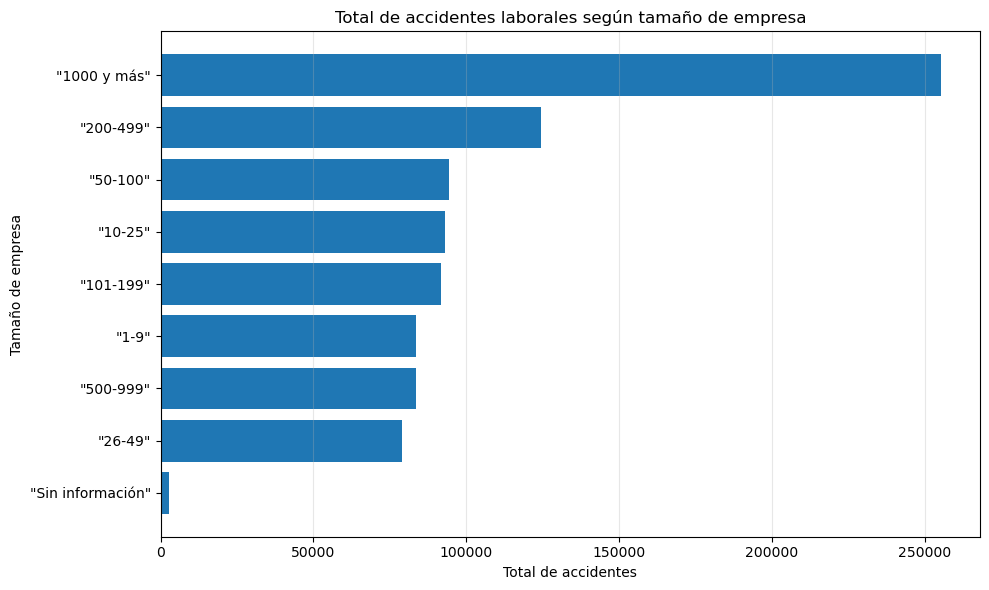

In [67]:
tamano_total = indicadores_tamano.sort_values("total_accidentes")

plt.figure(figsize=(10, 6))

plt.barh(
    tamano_total["tamano_de_empresa"],
    tamano_total["total_accidentes"]
)

plt.xlabel("Total de accidentes")
plt.ylabel("Tamaño de empresa")
plt.title("Total de accidentes laborales según tamaño de empresa")

plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

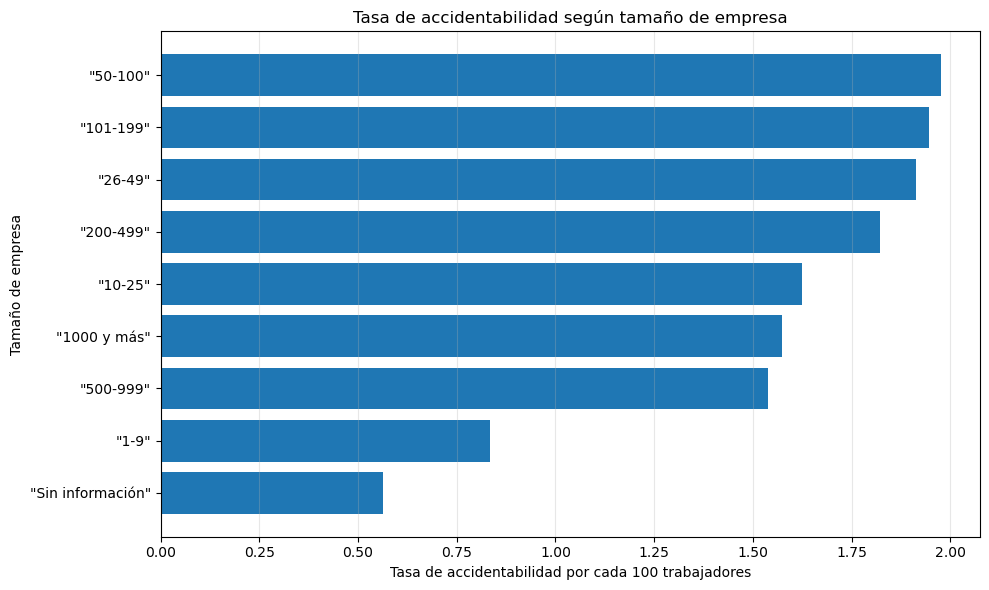

In [68]:
tamano_tasa = indicadores_tamano.sort_values("tasa_accidentabilidad")

plt.figure(figsize=(10, 6))

plt.barh(
    tamano_tasa["tamano_de_empresa"],
    tamano_tasa["tasa_accidentabilidad"]
)

plt.xlabel("Tasa de accidentabilidad por cada 100 trabajadores")
plt.ylabel("Tamaño de empresa")
plt.title("Tasa de accidentabilidad según tamaño de empresa")

plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretación del análisis según tamaño de empresa

El análisis según tamaño de empresa muestra que las empresas de mayor dotación concentran la mayor cantidad absoluta de accidentes laborales. Esto puede explicarse por el mayor número de trabajadores protegidos, mayor volumen de operaciones y mayor exposición acumulada a riesgos laborales.

Sin embargo, al observar la tasa de accidentabilidad por cada 100 trabajadores protegidos, la diferencia entre tamaños de empresa se reduce. Esto permite identificar que no basta con analizar el número total de accidentes, ya que las empresas con mayor cantidad de trabajadores tienden naturalmente a concentrar más eventos.

Desde una perspectiva preventiva, la tasa de accidentabilidad entrega una mirada más comparable entre tamaños de empresa, permitiendo evaluar el riesgo relativo y orientar estrategias preventivas diferenciadas según la realidad de cada grupo.

Este análisis refuerza la importancia de utilizar indicadores relativos junto con los conteos absolutos para apoyar una mejor toma de decisiones en prevención de riesgos laborales.


## 14. Accidentabilidad según sexo

En esta sección se analiza la distribución de accidentes laborales según sexo, utilizando las columnas de hombres, mujeres y registros sin información.

El objetivo es observar la participación de cada grupo en el total de accidentes registrados y analizar su evolución durante el periodo estudiado.

Este análisis permite incorporar una mirada demográfica básica dentro de la accidentabilidad laboral, aportando información útil para caracterizar mejor los eventos registrados.


In [69]:
# Accidentes anuales según sexo
accidentes_sexo_anual = (
    df_acc[df_acc["anio"].isin(indicadores_anuales_completos["anio"])]
    .groupby("anio")
    .agg(
        mujeres=("mujer", "sum"),
        hombres=("hombre", "sum"),
        sin_informacion=("sin_informacion", "sum"),
        total_accidentes=("total", "sum")
    )
    .reset_index()
)

accidentes_sexo_anual

,anio,mujeres,hombres,sin_informacion,total_accidentes
0,2015,82648.0,150017.0,0.0,232665.0
1,2016,84397.0,147202.0,0.0,231599.0
2,2017,82622.0,142081.0,0.0,224703.0
3,2018,79844.0,138158.0,0.0,218002.0
4,2019,80853.0,136958.0,0.0,217811.0
5,2020,46787.0,106042.0,0.0,152829.0
6,2021,61008.0,125204.0,0.0,186212.0
7,2022,83009.0,131531.0,0.0,214540.0
8,2023,83503.0,123944.0,0.0,207447.0
9,2024,84327.0,116456.0,0.0,200783.0


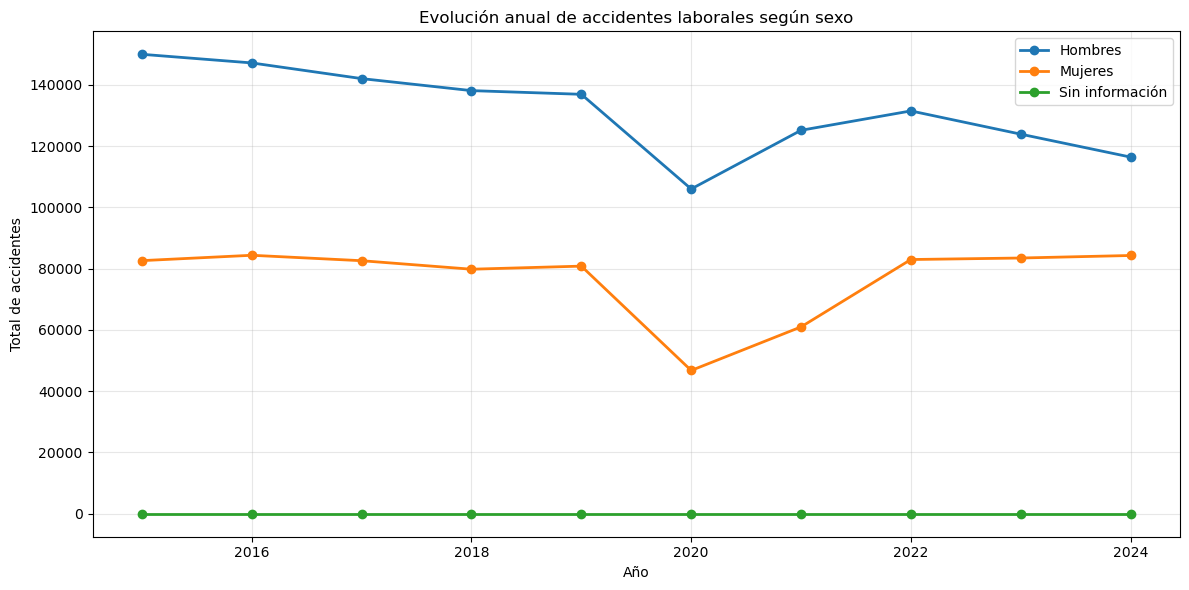

In [70]:
plt.figure(figsize=(12, 6))

plt.plot(
    accidentes_sexo_anual["anio"],
    accidentes_sexo_anual["hombres"],
    marker="o",
    linewidth=2,
    label="Hombres"
)

plt.plot(
    accidentes_sexo_anual["anio"],
    accidentes_sexo_anual["mujeres"],
    marker="o",
    linewidth=2,
    label="Mujeres"
)

plt.plot(
    accidentes_sexo_anual["anio"],
    accidentes_sexo_anual["sin_informacion"],
    marker="o",
    linewidth=2,
    label="Sin información"
)

plt.xlabel("Año")
plt.ylabel("Total de accidentes")
plt.title("Evolución anual de accidentes laborales según sexo")

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [71]:
accidentes_sexo_pct = accidentes_sexo_anual.copy()

accidentes_sexo_pct["porcentaje_hombres"] = (
    accidentes_sexo_pct["hombres"] / accidentes_sexo_pct["total_accidentes"] * 100
)

accidentes_sexo_pct["porcentaje_mujeres"] = (
    accidentes_sexo_pct["mujeres"] / accidentes_sexo_pct["total_accidentes"] * 100
)

accidentes_sexo_pct["porcentaje_sin_informacion"] = (
    accidentes_sexo_pct["sin_informacion"] / accidentes_sexo_pct["total_accidentes"] * 100
)

accidentes_sexo_pct[
    ["anio", "porcentaje_hombres", "porcentaje_mujeres", "porcentaje_sin_informacion"]
]

,anio,porcentaje_hombres,porcentaje_mujeres,porcentaje_sin_informacion
0,2015,64.477683,35.522317,0.0
1,2016,63.558996,36.441004,0.0
2,2017,63.230575,36.769425,0.0
3,2018,63.374648,36.625352,0.0
4,2019,62.879285,37.120715,0.0
5,2020,69.386046,30.613954,0.0
6,2021,67.237342,32.762658,0.0
7,2022,61.308381,38.691619,0.0
8,2023,59.747309,40.252691,0.0
9,2024,58.000926,41.999074,0.0


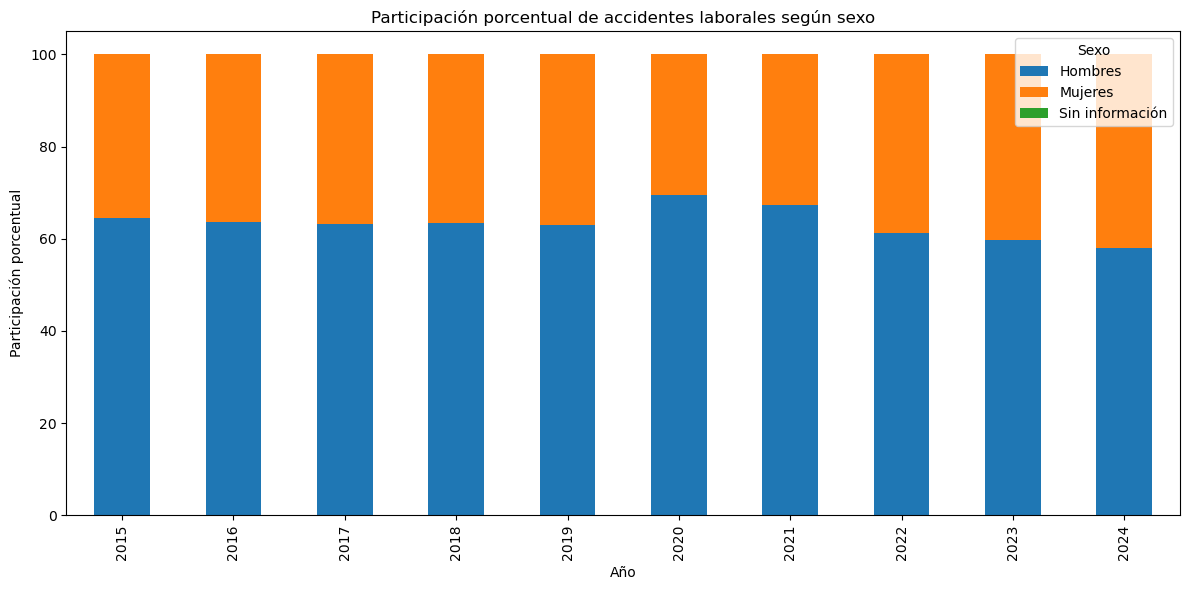

In [72]:
tabla_sexo_pct = accidentes_sexo_pct.set_index("anio")[
    ["porcentaje_hombres", "porcentaje_mujeres", "porcentaje_sin_informacion"]
]

tabla_sexo_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.xlabel("Año")
plt.ylabel("Participación porcentual")
plt.title("Participación porcentual de accidentes laborales según sexo")

plt.legend(["Hombres", "Mujeres", "Sin información"], title="Sexo")
plt.tight_layout()
plt.show()

### Interpretación del análisis según sexo

El análisis según sexo muestra que los accidentes laborales registrados se concentran principalmente en hombres durante todo el periodo analizado, mientras que las mujeres representan una proporción menor del total anual.

En 2020 se observa una disminución marcada tanto en hombres como en mujeres, lo que podría estar asociado al contexto de la pandemia por COVID-19, menor presencialidad laboral, restricciones de movilidad y cambios en la operación normal de distintas actividades económicas.

El gráfico porcentual permite observar que la distribución entre hombres y mujeres se mantiene relativamente estable, aunque con ciertas variaciones hacia los últimos años del periodo.

Este análisis debe interpretarse con cautela, ya que la mayor cantidad absoluta de accidentes en hombres puede estar influenciada por la distribución de trabajadores según sexo en sectores económicos de mayor exposición a riesgos laborales, como construcción, manufactura, transporte, agricultura o actividades operacionales.

Por esta razón, para complementar la lectura, resulta recomendable calcular una tasa de accidentabilidad según sexo, relacionando los accidentes con la cantidad de trabajadores protegidos hombres y mujeres.


## 15. Tasa de accidentabilidad según sexo

En esta sección se calcula la tasa de accidentabilidad según sexo, relacionando los accidentes registrados en hombres y mujeres con la cantidad promedio de trabajadores protegidos de cada grupo.

Este análisis permite comparar la accidentabilidad relativa y no solo la cantidad absoluta de accidentes.

In [75]:
# Accidentes mensuales por sexo
accidentes_sexo_mensual = (
    df_acc[df_acc["anio"].isin(indicadores_anuales_completos["anio"])]
    .groupby(["anio", "mes"])
    .agg(
        accidentes_mujeres=("mujer", "sum"),
        accidentes_hombres=("hombre", "sum")
    )
    .reset_index()
)

# Trabajadores protegidos mensuales por sexo
trabajadores_sexo_mensual = (
    df_trab[df_trab["anio"].isin(indicadores_anuales_completos["anio"])]
    .groupby(["anio", "mes"])
    .agg(
        trabajadores_mujeres=("mujer", "sum"),
        trabajadores_hombres=("hombre", "sum")
    )
    .reset_index()
)

# Resumen anual de accidentes
accidentes_sexo_anual_tasa = (
    accidentes_sexo_mensual
    .groupby("anio")
    .agg(
        accidentes_mujeres=("accidentes_mujeres", "sum"),
        accidentes_hombres=("accidentes_hombres", "sum")
    )
    .reset_index()
)

# Promedio anual de trabajadores protegidos
trabajadores_sexo_anual_tasa = (
    trabajadores_sexo_mensual
    .groupby("anio")
    .agg(
        promedio_mujeres=("trabajadores_mujeres", "mean"),
        promedio_hombres=("trabajadores_hombres", "mean")
    )
    .reset_index()
)

# Unión
indicadores_sexo_tasa = accidentes_sexo_anual_tasa.merge(
    trabajadores_sexo_anual_tasa,
    on="anio",
    how="inner"
)

# Tasas por cada 100 trabajadores protegidos
indicadores_sexo_tasa["tasa_mujeres"] = (
    indicadores_sexo_tasa["accidentes_mujeres"] /
    indicadores_sexo_tasa["promedio_mujeres"] * 100
)

indicadores_sexo_tasa["tasa_hombres"] = (
    indicadores_sexo_tasa["accidentes_hombres"] /
    indicadores_sexo_tasa["promedio_hombres"] * 100
)

indicadores_sexo_tasa

,anio,accidentes_mujeres,accidentes_hombres,promedio_mujeres,promedio_hombres,tasa_mujeres,tasa_hombres
0,2015,82648.0,150017.0,2.255551e+06,3.392431e+06,3.664204,4.422109
1,2016,84397.0,147202.0,2.277878e+06,3.458551e+06,3.705071,4.256175
2,2017,82622.0,142081.0,2.345042e+06,3.466276e+06,3.523264,4.098953
3,2018,79844.0,138158.0,2.460588e+06,3.645338e+06,3.244915,3.789991
4,2019,80853.0,136958.0,2.701909e+06,3.732774e+06,2.992440,3.669068
5,2020,46787.0,106042.0,2.741660e+06,3.713929e+06,1.706521,2.855251
6,2021,61008.0,125204.0,2.864967e+06,3.866043e+06,2.129449,3.238556
7,2022,83009.0,131531.0,3.055344e+06,3.992349e+06,2.716846,3.294577
8,2023,83503.0,123944.0,3.102975e+06,3.966957e+06,2.691063,3.124410
9,2024,84327.0,116456.0,3.133360e+06,3.958892e+06,2.691265,2.941631


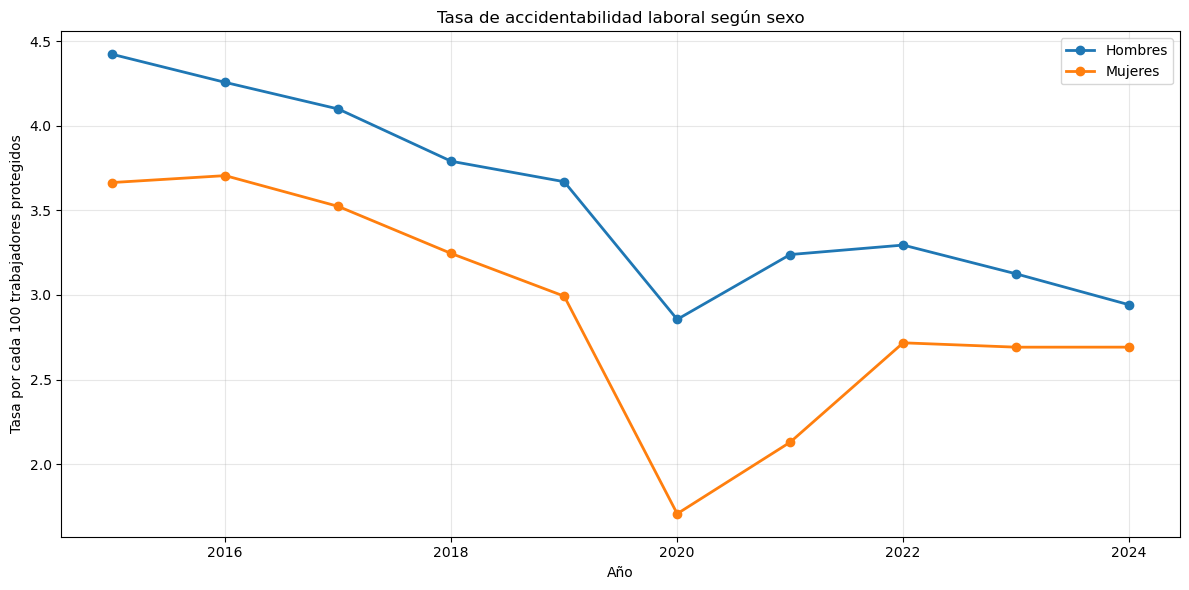

In [76]:
plt.figure(figsize=(12, 6))

plt.plot(
    indicadores_sexo_tasa["anio"],
    indicadores_sexo_tasa["tasa_hombres"],
    marker="o",
    linewidth=2,
    label="Hombres"
)

plt.plot(
    indicadores_sexo_tasa["anio"],
    indicadores_sexo_tasa["tasa_mujeres"],
    marker="o",
    linewidth=2,
    label="Mujeres"
)

plt.xlabel("Año")
plt.ylabel("Tasa por cada 100 trabajadores protegidos")
plt.title("Tasa de accidentabilidad laboral según sexo")

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Interpretación de la tasa de accidentabilidad según sexo

La tasa de accidentabilidad según sexo muestra que los hombres presentan una tasa superior a la de las mujeres durante todo el periodo analizado.

Entre 2015 y 2019 se observa una disminución progresiva de la tasa en ambos grupos, lo que indica una reducción relativa de accidentes en relación con la cantidad de trabajadores protegidos.

En 2020 se aprecia una caída marcada, especialmente en mujeres, situación que podría estar asociada al contexto de la pandemia por COVID-19, menor presencialidad laboral, restricciones de movilidad y cambios en la operación normal de distintas actividades económicas.

Posteriormente, entre 2021 y 2022 se observa una recuperación parcial de la tasa, aunque sin volver a los niveles registrados al inicio del periodo. Hacia 2023 y 2024 la tasa vuelve a estabilizarse en niveles menores que los observados entre 2015 y 2019.

Desde una perspectiva preventiva, este análisis permite comparar la accidentabilidad relativa entre hombres y mujeres, evitando interpretar solo cantidades absolutas. No obstante, las diferencias observadas deben analizarse considerando la distribución de hombres y mujeres por sector económico, tipo de trabajo, exposición a riesgos operacionales y nivel de presencialidad.


## 16. Conclusiones ejecutivas

El análisis de accidentabilidad laboral en Chile permitió transformar datos públicos de la SUSESO en información útil para la gestión preventiva y la toma de decisiones basada en evidencia.

En primer lugar, se observó una disminución general de los accidentes laborales entre 2015 y 2019, seguida de una caída marcada en 2020. Esta disminución podría estar influenciada por el contexto de la pandemia por COVID-19, la reducción de presencialidad, restricciones de movilidad y cambios en la operación normal de diversas actividades económicas. Posteriormente, entre 2021 y 2022 se aprecia una recuperación parcial, aunque sin volver completamente a los niveles iniciales del periodo.

El análisis por origen del accidente mostró que los accidentes del trabajo representan la mayor proporción del total anual, mientras que los accidentes de trayecto mantienen una participación menor, pero relevante. Esta distinción permite diferenciar estrategias preventivas asociadas al lugar de trabajo y al desplazamiento de las personas trabajadoras.

Al calcular la tasa de accidentabilidad por cada 100 trabajadores protegidos, se obtuvo una visión más precisa que el conteo absoluto de accidentes. Este indicador permitió observar que la accidentabilidad relativa también presenta una tendencia descendente durante el periodo analizado, reforzando la importancia de utilizar tasas y no solo volúmenes totales.

El análisis regional evidenció que la Región Metropolitana concentra la mayor cantidad absoluta de accidentes, lo que se explica por su alta concentración de trabajadores y actividad económica. Sin embargo, al observar la tasa de accidentabilidad, algunas regiones presentan mayor accidentabilidad relativa, demostrando que el volumen de accidentes no siempre representa el mayor nivel de riesgo proporcional.

Por actividad económica, sectores como comercio, construcción, manufactura, transporte y actividades administrativas concentran una parte importante de los accidentes. No obstante, al analizar tasas, sectores como manufactura, construcción, pesca, transporte y agricultura destacan por mayor accidentabilidad relativa, lo que sugiere una mayor exposición operacional a riesgos laborales.

Los análisis por forma del accidente, parte del cuerpo afectada y agente del accidente permitieron identificar focos preventivos concretos. Se observaron como relevantes las caídas de personas, accidentes con vehículos, objetos corto-punzantes, golpes, sobreesfuerzos, miembros superiores e inferiores, herramientas, materiales, vehículos, máquinas y condiciones del entorno de trabajo.

También se identificó una alta presencia de registros clasificados como “Sin Información” en algunas variables, lo que representa una oportunidad de mejora en la calidad del registro de accidentes. Una mejor clasificación permitiría obtener diagnósticos preventivos más precisos y orientar acciones de control con mayor efectividad.

En conjunto, este proyecto demuestra cómo el análisis de datos puede apoyar la prevención de riesgos laborales, permitiendo identificar tendencias, sectores críticos, diferencias regionales, mecanismos frecuentes de accidente y oportunidades de mejora en la gestión preventiva.


## 17. Próximos pasos

Como próximos pasos, se recomienda profundizar el análisis mediante:

* Construcción de indicadores por sector económico y región.
* Análisis combinado entre forma del accidente, agente y parte del cuerpo afectada.
* Segmentación por tamaño de empresa y organismo administrador.
* Evaluación de tendencias mensuales o estacionales.
* Desarrollo de un dashboard interactivo para seguimiento de indicadores preventivos.
* Incorporación de variables externas, como actividad económica, empleo, presencialidad o movilidad, para contextualizar mejor los cambios observados durante el periodo.

Estos avances permitirían transformar el análisis exploratorio en una herramienta de apoyo a la gestión preventiva, fiscalización, planificación de campañas y toma de decisiones en seguridad y salud en el trabajo.


## 18. Exportación de tablas resumen

En esta sección se exportan las principales tablas generadas durante el análisis a archivos CSV.

Esto permite dejar disponibles los resultados procesados fuera del notebook, facilitando su uso posterior en reportes, dashboards, Tableau, Power BI o documentación del proyecto.

In [77]:
from pathlib import Path

# Crear carpetas de salida si no existen
ruta_reportes = Path("../outputs/reportes")
ruta_reportes.mkdir(parents=True, exist_ok=True)

# Exportar tablas principales
accidentes_anuales_completos.to_csv(
    ruta_reportes / "accidentes_anuales_completos.csv",
    index=False,
    encoding="utf-8-sig"
)

accidentes_origen_pct.to_csv(
    ruta_reportes / "participacion_accidentes_por_origen.csv",
    index=False,
    encoding="utf-8-sig"
)

indicadores_anuales_completos.to_csv(
    ruta_reportes / "tasa_accidentabilidad_anual.csv",
    index=False,
    encoding="utf-8-sig"
)

indicadores_region.to_csv(
    ruta_reportes / "indicadores_region.csv",
    index=False,
    encoding="utf-8-sig"
)

indicadores_actividad.to_csv(
    ruta_reportes / "indicadores_actividad_economica.csv",
    index=False,
    encoding="utf-8-sig"
)

indicadores_organismo.to_csv(
    ruta_reportes / "indicadores_organismo_administrador.csv",
    index=False,
    encoding="utf-8-sig"
)

accidentes_forma.to_csv(
    ruta_reportes / "accidentes_por_forma.csv",
    index=False,
    encoding="utf-8-sig"
)

accidentes_parte_cuerpo.to_csv(
    ruta_reportes / "accidentes_por_parte_cuerpo.csv",
    index=False,
    encoding="utf-8-sig"
)

accidentes_agente.to_csv(
    ruta_reportes / "accidentes_por_agente.csv",
    index=False,
    encoding="utf-8-sig"
)

indicadores_tamano.to_csv(
    ruta_reportes / "indicadores_tamano_empresa.csv",
    index=False,
    encoding="utf-8-sig"
)

indicadores_sexo_tasa.to_csv(
    ruta_reportes / "tasa_accidentabilidad_sexo.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Tablas exportadas correctamente en outputs/reportes")

Tablas exportadas correctamente en outputs/reportes


In [78]:
archivos_reportes = list(ruta_reportes.glob("*.csv"))

for archivo in archivos_reportes:
    print(archivo.name)

accidentes_anuales_completos.csv
accidentes_por_agente.csv
accidentes_por_forma.csv
accidentes_por_parte_cuerpo.csv
indicadores_actividad_economica.csv
indicadores_organismo_administrador.csv
indicadores_region.csv
indicadores_tamano_empresa.csv
participacion_accidentes_por_origen.csv
tasa_accidentabilidad_anual.csv
tasa_accidentabilidad_sexo.csv


## 19. Exportación de gráficos principales

En esta sección se guardan los principales gráficos del análisis en formato PNG.

Esto permite utilizar las visualizaciones fuera del notebook, por ejemplo en GitHub, LinkedIn, presentaciones, reportes ejecutivos o dashboards complementarios.

In [79]:
# Crear carpeta de gráficos
ruta_graficos = Path("../outputs/graficos")
ruta_graficos.mkdir(parents=True, exist_ok=True)

def acortar_texto(texto, largo=60):
    texto = str(texto)
    return texto if len(texto) <= largo else texto[:largo] + "..."

In [80]:
# 1. Evolución anual de accidentes laborales
plt.figure(figsize=(12, 6))
plt.plot(
    accidentes_anuales_completos["anio"],
    accidentes_anuales_completos["total_accidentes"],
    marker="o",
    linewidth=2
)
plt.xlabel("Año")
plt.ylabel("Total de accidentes")
plt.title("Evolución anual de accidentes laborales en Chile - años completos")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(ruta_graficos / "evolucion_anual_accidentes.png", dpi=300, bbox_inches="tight")
plt.close()


# 2. Accidentes según origen
plt.figure(figsize=(12, 6))

for origen in accidentes_origen_anual["origen"].unique():
    datos = accidentes_origen_anual[accidentes_origen_anual["origen"] == origen]
    datos = datos[datos["anio"].isin(accidentes_anuales_completos["anio"])]
    
    plt.plot(
        datos["anio"],
        datos["total_accidentes"],
        marker="o",
        linewidth=2,
        label=origen
    )

plt.xlabel("Año")
plt.ylabel("Total de accidentes")
plt.title("Evolución anual de accidentes según origen del evento")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(ruta_graficos / "accidentes_segun_origen.png", dpi=300, bbox_inches="tight")
plt.close()


# 3. Tasa anual de accidentabilidad
plt.figure(figsize=(12, 6))
plt.plot(
    indicadores_anuales_completos["anio"],
    indicadores_anuales_completos["tasa_accidentabilidad"],
    marker="o",
    linewidth=2
)
plt.xlabel("Año")
plt.ylabel("Tasa por cada 100 trabajadores protegidos")
plt.title("Tasa anual de accidentabilidad laboral en Chile")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(ruta_graficos / "tasa_anual_accidentabilidad.png", dpi=300, bbox_inches="tight")
plt.close()


# 4. Top regiones por total de accidentes
top_regiones_accidentes = indicadores_region.head(10).sort_values("total_accidentes")

plt.figure(figsize=(12, 7))
plt.barh(
    top_regiones_accidentes["region"],
    top_regiones_accidentes["total_accidentes"]
)
plt.xlabel("Total de accidentes")
plt.ylabel("Región")
plt.title("Top 10 regiones con mayor cantidad de accidentes laborales")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(ruta_graficos / "top_regiones_total_accidentes.png", dpi=300, bbox_inches="tight")
plt.close()


# 5. Top actividades económicas por tasa
top_actividades_tasa = indicadores_actividad.sort_values(
    "tasa_accidentabilidad",
    ascending=False
).head(10).copy()

top_actividades_tasa["actividad_corta"] = top_actividades_tasa["actividad_economica_ciiu"].apply(
    lambda x: acortar_texto(x, 60)
)

top_actividades_tasa = top_actividades_tasa.sort_values("tasa_accidentabilidad")

plt.figure(figsize=(12, 7))
plt.barh(
    top_actividades_tasa["actividad_corta"],
    top_actividades_tasa["tasa_accidentabilidad"]
)
plt.xlabel("Tasa de accidentabilidad por cada 100 trabajadores")
plt.ylabel("Actividad económica")
plt.title("Top 10 actividades económicas con mayor tasa de accidentabilidad")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(ruta_graficos / "top_actividades_tasa_accidentabilidad.png", dpi=300, bbox_inches="tight")
plt.close()


# 6. Formas de accidente sin información excluida
top_formas_accidente_filtrado = accidentes_forma_filtrado.head(10).copy()
top_formas_accidente_filtrado["forma_corta"] = top_formas_accidente_filtrado["forma_del_accidente"].apply(
    lambda x: acortar_texto(x, 60)
)
top_formas_accidente_filtrado = top_formas_accidente_filtrado.sort_values("total_accidentes")

plt.figure(figsize=(12, 7))
plt.barh(
    top_formas_accidente_filtrado["forma_corta"],
    top_formas_accidente_filtrado["total_accidentes"]
)
plt.xlabel("Total de accidentes")
plt.ylabel("Forma del accidente")
plt.title("Top 10 formas de accidente más frecuentes, excluyendo registros sin información")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(ruta_graficos / "top_formas_accidente_filtrado.png", dpi=300, bbox_inches="tight")
plt.close()


# 7. Parte del cuerpo afectada sin información excluida
top_partes_cuerpo_filtrado = accidentes_parte_cuerpo_filtrado.head(10).copy()
top_partes_cuerpo_filtrado["parte_corta"] = top_partes_cuerpo_filtrado["parte_del_cuerpo"].apply(
    lambda x: acortar_texto(x, 60)
)
top_partes_cuerpo_filtrado = top_partes_cuerpo_filtrado.sort_values("total_accidentes")

plt.figure(figsize=(12, 7))
plt.barh(
    top_partes_cuerpo_filtrado["parte_corta"],
    top_partes_cuerpo_filtrado["total_accidentes"]
)
plt.xlabel("Total de accidentes")
plt.ylabel("Parte del cuerpo afectada")
plt.title("Top 10 partes del cuerpo afectadas, excluyendo registros sin información")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(ruta_graficos / "top_partes_cuerpo_filtrado.png", dpi=300, bbox_inches="tight")
plt.close()


# 8. Tasa de accidentabilidad según sexo
plt.figure(figsize=(12, 6))
plt.plot(
    indicadores_sexo_tasa["anio"],
    indicadores_sexo_tasa["tasa_hombres"],
    marker="o",
    linewidth=2,
    label="Hombres"
)
plt.plot(
    indicadores_sexo_tasa["anio"],
    indicadores_sexo_tasa["tasa_mujeres"],
    marker="o",
    linewidth=2,
    label="Mujeres"
)
plt.xlabel("Año")
plt.ylabel("Tasa por cada 100 trabajadores protegidos")
plt.title("Tasa de accidentabilidad laboral según sexo")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(ruta_graficos / "tasa_accidentabilidad_sexo.png", dpi=300, bbox_inches="tight")
plt.close()

print("Gráficos exportados correctamente en outputs/graficos")

Gráficos exportados correctamente en outputs/graficos


In [81]:
archivos_graficos = list(ruta_graficos.glob("*.png"))

for archivo in archivos_graficos:
    print(archivo.name)

accidentes_segun_origen.png
evolucion_anual_accidentes.png
tasa_accidentabilidad_sexo.png
tasa_anual_accidentabilidad.png
top_actividades_tasa_accidentabilidad.png
top_formas_accidente_filtrado.png
top_partes_cuerpo_filtrado.png
top_regiones_total_accidentes.png
